# Detección de Agentes Automatizados en Redes Sociales

**Autores:** Julián Santiago Flórez Castañeda, Camila Andrea Peña Caballero, Samuel Kalell Zuñiga Molina
**Curso:** Seminario de Investigación
**Docente:** Diego Armando García García
**Universidad EAN – Ingeniería de Sistemas – Bogotá D.C. – 2026**

---

## Objetivo del proyecto
Desarrollar un enfoque para la identificación de agentes automatizados en redes sociales basado en características conductuales, temporales y lingüísticas, y analizar su influencia en las métricas de inmersión.

## Alcance y límites
- El análisis se realiza sobre un dataset académico de 2017 con cuentas etiquetadas como genuinas/humanas y spam/bots.
- Se extraen y analizan features conductuales, temporales y lingüísticas.
- Se entrenan y evalúan modelos supervisados y no supervisados.
- Se comparan métricas de inmersión entre cuentas humanas y automatizadas.
- Limitaciones: antigüedad y posible sesgo de etiquetado del dataset; no se recolectan datos actuales desde la API de X.

## Resumen
El uso creciente de agentes automatizados impulsados por IA en redes sociales genera desafíos para la autenticidad de la interacción digital y la confiabilidad de las métricas de participación. Este estudio desarrolla un enfoque para identificar cuentas automatizadas en X (antes Twitter) mediante el análisis combinado de características conductuales, temporales y lingüísticas, evaluando su impacto en los niveles de interacción. Se utiliza un dataset académico de 2017 con cuentas etiquetadas, extrayendo rasgos y entrenando modelos de clasificación. Los resultados aportan evidencia sobre patrones discriminativos y criterios útiles para la detección de bots en datos históricos.

## Objetivos específicos
1. Identificar patrones de comportamiento que diferencien cuentas humanas de automatizadas.
2. Definir características temporales asociadas a la actividad de agentes automatizados.
3. Analizar patrones lingüísticos presentes en publicaciones automatizadas.
4. Comparar el nivel de inmersión entre cuentas humanas y agentes automatizados.
5. Evaluar la efectividad de los criterios definidos para la clasificación de cuentas.

## Catálogo de datasets
- **Fuente:** Dataset académico Cresci 2017
- **Descripción:** Colección de cuentas genuinas, tradicionales, spambots y fake followers, con archivos de usuarios y tweets.
- **Estructura:**
    - genuine_accounts: tweets.csv, users.csv
    - social_spambots_1/2/3: tweets.csv, users.csv
    - traditional_spambots_1/2/3/4: tweets.csv, users.csv
    - fake_followers: tweets.csv, users.csv
    - crowdflower_results: crowdflower_results_aggregated.csv, contributors.csv, detailed.csv

## Metodología resumida
- Análisis cuantitativo, descriptivo y correlacional sobre cuentas humanas y automatizadas.
- Extracción de features conductuales, temporales y lingüísticas.
- Clasificación supervisada y clustering.
- Comparación de métricas de inmersión.
- Evaluación de modelos con métricas estándar (accuracy, precision, recall).
- Uso exclusivo de datos públicos y etiquetados, respetando condiciones éticas y legales.

## 01. Configuracion del entorno y librerias
- Nombre exacto de la seccion: Configuracion del entorno y librerias
- Objetivo tecnico: Preparar el entorno de ejecucion, dependencias y configuracion global
- Subsecciones / bloques: Configuracion del entorno; Importacion de librerias; Configuracion global
- Tipo de codigo: Configuracion, importaciones, flags globales
- Datos entran: No aplica
- Datos salen: `env_info`, `lib_versions`, `GLOBAL_CONFIG`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Versiones minimas, disponibilidad de GPU/CPU, rutas accesibles
- Transformaciones: Seteo de opciones globales y formato de salida
- Errores a controlar: Librerias faltantes, conflictos de versiones
- Resultados a guardar: `env_snapshot.json`
- Artefactos a exportar: `requirements_lock.txt`
- Variables sugeridas: `SEED`, `RANDOM_STATE`, `GLOBAL_CONFIG`, `RUN_ID`
- Checkpoint / cache: No aplica
- Notas de modularizacion: Encapsular en funcion `init_environment()`
- Reproducibilidad: Registrar versiones y seed al inicio
- Placeholder: agregar codigo en la celda inferior para inicializacion

In [1]:
# --- Configuración global y seeds
import os
import sys
import random
import warnings
import logging
import platform
from pathlib import Path

import numpy as np
import pandas as pd

# --- Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# --- Procesamiento de texto y NLP
import re
import unicodedata
import nltk
import spacy
from nltk.corpus import stopwords

# --- Machine Learning y Modelado
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# --- NLP avanzado y embeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
# (Opcional: transformers para embeddings avanzados)
# from transformers import AutoTokenizer, AutoModel

# --- Interpretabilidad
import shap
import lime

# --- Utilidades y reproducibilidad
import json
import hashlib
import datetime

# --- Configuración de warnings y logs
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

# --- Variables globales sugeridas
SEED = 42
RANDOM_STATE = 42
GLOBAL_CONFIG = {}
RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
np.random.seed(SEED)
random.seed(SEED)

# --- Información del entorno
env_info = {
    'python_version': platform.python_version(),
    'os': platform.system(),
    'os_version': platform.version(),
    'cpu': platform.processor(),
    'ram_gb': round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024.**3), 2) if hasattr(os, 'sysconf') else None,
    'working_dir': os.getcwd(),
    'timestamp': RUN_ID
}

# --- Guardar snapshot de entorno
with open('env_snapshot.json', 'w') as f:
    json.dump(env_info, f, indent=2)

# --- Mostrar versiones principales
print('Python:', env_info['python_version'])
print('Pandas:', pd.__version__)
print('Numpy:', np.__version__)
print('Scikit-learn:', sys.modules['sklearn'].__version__)
print('NLTK:', nltk.__version__)
print('spaCy:', spacy.__version__)
print('Matplotlib:', plt.matplotlib.__version__)
print('Seaborn:', sns.__version__)
print('SHAP:', shap.__version__)

Python: 3.10.11
Pandas: 2.3.3
Numpy: 2.2.6
Scikit-learn: 1.7.2
NLTK: 3.9.4
spaCy: 3.8.14
Matplotlib: 3.10.0
Seaborn: 0.13.2
SHAP: 0.49.1


c:\Users\Julian\Documents\Uni\Seminario de Investigacion\dataset\cresci-2017.csv\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 02. Reproducibilidad, higiene y modularizacion del notebook
- Nombre exacto de la seccion: Reproducibilidad, higiene y modularizacion del notebook
- Objetivo tecnico: Establecer reglas para ejecucion determinista y evitar notebooks desordenados
- Subsecciones / bloques: Seeds y determinismo; Orden de ejecucion; Modularizacion; Cache y persistencia
- Tipo de codigo: Configuracion de seeds, helpers y wrappers
- Datos entran: No aplica
- Datos salen: `repro_config`, `cache_policy`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Verificar determinismo entre ejecuciones
- Transformaciones: No aplica
- Errores a controlar: Resultados no reproducibles, orden de celdas inconsistente
- Resultados a guardar: `reproducibility_notes.md`
- Artefactos a exportar: `run_config.yaml`
- Variables sugeridas: `SEED`, `CACHE_DIR`, `ARTIFACTS_DIR`
- Checkpoint / cache: Definir puntos de guardado por etapa
- Notas de modularizacion: Crear modulos `io.py`, `features.py`, `models.py`
- Reproducibilidad: Fijar seeds y loggear versiones en cada run
- Placeholder: agregar codigo en la celda inferior para reglas de ejecucion

In [2]:
# --- 02. Reproducibilidad, higiene y modularización del notebook
# Configuración de seeds, helpers y reglas para ejecución determinista

import os
import sys
import random
import numpy as np
import hashlib
import json
import datetime
import logging
from pathlib import Path

# --- Variables y rutas globales para reproducibilidad
SEED = 42
CACHE_DIR = Path('output/cache')
ARTIFACTS_DIR = Path('output/artifacts')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Configuración de seeds para determinismo
random.seed(SEED)
np.random.seed(SEED)

# --- Helper para fijar seeds en frameworks adicionales (si aplica)
def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

set_global_seed(SEED)

# --- Configuración de logging para reproducibilidad
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s',
    handlers=[
        logging.FileHandler(ARTIFACTS_DIR / f'run_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.log'),
        logging.StreamHandler(sys.stdout)
    ]
)

# --- Configuración de orden de ejecución y control de celdas
# (Recomendación: ejecutar notebook de arriba hacia abajo, evitar saltos)

# --- Configuración de cache y persistencia
repro_config = {
    'seed': SEED,
    'cache_dir': str(CACHE_DIR),
    'artifacts_dir': str(ARTIFACTS_DIR),
    'run_timestamp': datetime.datetime.now().isoformat(),
    'python_version': sys.version,
    'notebook': os.path.basename(sys.argv[0]) if hasattr(sys, 'argv') and sys.argv else None
}

cache_policy = {
    'enabled': True,
    'checkpoint_stages': [
        'raw_load', 'cleaning', 'feature_engineering', 'modeling', 'evaluation'
    ],
    'format': 'parquet',
    'hash_function': 'sha256'
}

# --- Guardar configuración de reproducibilidad y cache
with open(ARTIFACTS_DIR / 'run_config.yaml', 'w') as f:
    import yaml
    yaml.dump(repro_config, f)
with open(ARTIFACTS_DIR / 'cache_policy.json', 'w') as f:
    json.dump(cache_policy, f, indent=2)

# --- Guardar notas de reproducibilidad
with open(ARTIFACTS_DIR / 'reproducibility_notes.md', 'w') as f:
    f.write("""
# Notas de reproducibilidad
- Seed global fijado en {seed}
- Configuración de cache y artefactos en carpetas dedicadas
- Logging de cada run en archivo único
- Se recomienda ejecutar el notebook de arriba hacia abajo sin saltos
- Versiones de librerías y entorno registradas en la sección de configuración
""".format(seed=SEED))

logging.info('Configuración de reproducibilidad y cache inicializada.')

2026-05-22 10:01:18,149 INFO Configuración de reproducibilidad y cache inicializada.


## 03. Definicion de paths y carga de datasets
- Nombre exacto de la seccion: Definicion de paths y carga de datasets
- Objetivo tecnico: Centralizar rutas y cargar datos crudos de forma trazable
- Subsecciones / bloques: Definicion de paths; Carga de datasets
- Tipo de codigo: I/O, lectura de CSV/Parquet, validacion de rutas
- Datos entran: Archivos crudos en `DATA_DIR`
- Datos salen: `df_raw`, `datasets_raw`
- Visualizaciones: No aplica (opcional tabla de conteos)
- Metricas: Cantidad de filas/columnas por dataset, tamanio en disco
- Validaciones: Existencia de archivos, encoding, delimitadores
- Transformaciones: Normalizacion minima de columnas (nombres)
- Errores a controlar: Archivos faltantes, parsing incorrecto
- Resultados a guardar: `data_inventory.csv`
- Artefactos a exportar: `raw_load_log.json`
- Variables sugeridas: `DATA_DIR`, `RAW_FILES`, `df_raw`
- Checkpoint / cache: Guardar `df_raw` en formato columna (parquet)
- Notas de modularizacion: Crear funcion `load_raw_data()`
- Reproducibilidad: Log de checksum y timestamp de carga
- Placeholder: agregar codigo en la celda inferior para I/O

In [3]:
# --- 03. Definición de paths y carga de datasets (versión robusta y parquet seguro)
# Carga todos los archivos .csv válidos encontrados en subcarpetas de DATA_DIR y corrige tipos para Parquet

import os
import pandas as pd
import json
import hashlib
import datetime
from pathlib import Path

# --- Definición de path raíz de datos
DATA_DIR = Path('datasets_full')

# --- Helper para calcular checksum de archivo
def file_checksum(path, algo='sha256'):
    h = hashlib.new(algo)
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(8192)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

# --- Función para buscar y cargar todos los CSV válidos (submuestreo 1 de cada 100 filas)
def load_all_csvs(data_dir=DATA_DIR):
    datasets_raw = {}
    inventory = []
    found = False
    for csv_path in data_dir.rglob('*.csv'):
        if csv_path.is_file() and csv_path.suffix == '.csv':
            found = True
            name = str(csv_path.relative_to(data_dir)).replace('\\', '/').replace('/', '__').replace('.csv', '')
            try:
                # Submuestreo eficiente: solo 1 de cada 500 filas al cargar
                df = pd.read_csv(csv_path, encoding='utf-8', delimiter=',', skiprows=lambda i: i != 0 and i % 500 != 0)
                df.columns = [c.strip().lower() for c in df.columns]
                datasets_raw[name] = df
                inventory.append({
                    'dataset': name,
                    'file': str(csv_path),
                    'rows': df.shape[0],
                    'cols': df.shape[1],
                    'size_mb': round(csv_path.stat().st_size / 1024**2, 2),
                    'checksum': file_checksum(csv_path),
                    'load_timestamp': datetime.datetime.now().isoformat(),
                    'submuestreo': '1 de cada 500 filas'
                })
            except Exception as e:
                print(f"[ERROR] Fallo al cargar {csv_path}: {e}")
    if not found:
        print(f"[ADVERTENCIA] No se encontraron archivos .csv en {data_dir.resolve()}.")
    # Guardar inventario
    inventory_df = pd.DataFrame(inventory)
    inventory_df.to_csv('data_inventory.csv', index=False)
    with open('raw_load_log.json', 'w') as f:
        json.dump(inventory, f, indent=2)
    return datasets_raw, inventory_df

# --- Carga de todos los CSVs válidos
datasets_raw, data_inventory = load_all_csvs()

if len(datasets_raw) == 0:
    print(f"[ERROR] No se cargó ningún archivo .csv. Verifica la ruta: {DATA_DIR.resolve()} y el contenido de las subcarpetas.")
else:
    # --- Unir todos los datasets en un solo DataFrame (opcional, según análisis)
    df_raw = pd.concat(datasets_raw.values(), ignore_index=True, sort=False)
    # --- Forzar columnas problemáticas a string para Parquet
    for col in df_raw.columns:
        if df_raw[col].dtype == object or 'color' in col or 'id' in col:
            try:
                df_raw[col] = df_raw[col].astype(str)
            except Exception:
                pass
    Path('output').mkdir(parents=True, exist_ok=True)
    # --- Guardar checkpoint en formato columna (parquet)
    df_raw.to_parquet('output/df_raw.parquet', index=False)
    # --- Mostrar resumen de datasets cargados
    print(data_inventory)


                                              dataset  \
0   crowdflower_results__crowdflower_results__crow...   
1   crowdflower_results__crowdflower_results__crow...   
2   crowdflower_results__crowdflower_results__crow...   
3   crowdflower_results____MACOSX__crowdflower_res...   
4   crowdflower_results____MACOSX__crowdflower_res...   
5   crowdflower_results____MACOSX__crowdflower_res...   
6              fake_followers__fake_followers__tweets   
7               fake_followers__fake_followers__users   
8          fake_followers____MACOSX__._fake_followers   
9   fake_followers____MACOSX__fake_followers__._tw...   
10  fake_followers____MACOSX__fake_followers__._users   
11                           genuine_accounts__tweets   
12                            genuine_accounts__users   
13                          social_spambots_1__tweets   
14                           social_spambots_1__users   
15                          social_spambots_2__tweets   
16                           so

## 04. Verificacion de integridad y auditoria estructural
- Nombre exacto de la seccion: Verificacion de integridad y auditoria estructural
- Objetivo tecnico: Detectar problemas de schema, calidad y consistencia antes de analizar
- Subsecciones / bloques: Verificacion de integridad; Auditoria de variables; Deteccion de problemas estructurales
- Tipo de codigo: Checks de schema, profiling liviano, reglas de calidad
- Datos entran: `df_raw`
- Datos salen: `integrity_report`, `schema_profile`
- Visualizaciones: Matriz de nulos, resumen de tipos
- Metricas: % nulos, duplicados, cardinalidad, rangos
- Validaciones: Unicidad de claves, tipos esperados, rangos validos
- Transformaciones: No aplica (solo diagnostico)
- Errores a controlar: Columnas faltantes, tipos mixtos
- Resultados a guardar: `integrity_report.json`
- Artefactos a exportar: `schema_snapshot.json`
- Variables sugeridas: `expected_schema`, `integrity_report`
- Checkpoint / cache: Guardar reporte antes de limpieza
- Notas de modularizacion: Funcion `validate_schema(df)`
- Reproducibilidad: Versionar reglas de validacion
- Placeholder: agregar codigo en la celda inferior para checks

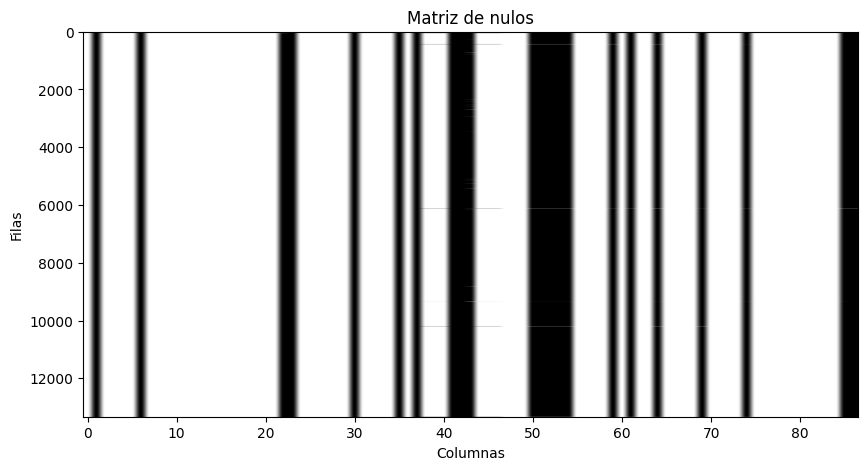

Resumen de tipos de columnas:


,tipo,nulos_%,cardinalidad
crowdflower_id,object,0.0000,27
trusted_answers,float64,0.9994,1
last_answer_at,object,0.0000,9
class,object,0.0000,3
class_confidence,object,0.0000,5
...,...,...,...
following,object,0.0000,1
updated,object,0.0000,8982
crawled_at,object,0.0000,8892
test_set_1,float64,0.9995,2


Problemas detectados: ['Alta proporción de nulos en trusted_answers: 99.9%', 'Alta proporción de nulos en comments: 100.0%', 'Alta proporción de nulos en trust: 99.8%', 'Alta proporción de nulos en comment: 100.0%', 'Alta proporción de nulos en truncated: 100.0%', 'Alta proporción de nulos en geo: 100.0%', 'Alta proporción de nulos en contributors: 100.0%', 'Alta proporción de nulos en favorited: 100.0%', 'Alta proporción de nulos en retweeted: 100.0%', 'Alta proporción de nulos en possibly_sensitive: 99.6%', 'Alta proporción de nulos en statuses_count: 99.8%', 'Alta proporción de nulos en followers_count: 99.8%', 'Alta proporción de nulos en friends_count: 99.8%', 'Alta proporción de nulos en favourites_count: 99.8%', 'Alta proporción de nulos en listed_count: 99.8%', 'Alta proporción de nulos en default_profile: 99.9%', 'Alta proporción de nulos en geo_enabled: 100.0%', 'Alta proporción de nulos en profile_use_background_image: 99.9%', 'Alta proporción de nulos en profile_background_

In [4]:
# --- 04. Verificación de integridad y auditoría estructural
# Diagnóstico previo: schema, nulos, duplicados, cardinalidad, tipos y rangos

import numpy as np
import pandas as pd
import json
from collections import Counter

# --- Variables de salida
integrity_report = {}
schema_profile = {}

# --- Auditoría de variables y tipos
schema_profile['column_types'] = df_raw.dtypes.apply(lambda x: str(x)).to_dict()
schema_profile['n_columns'] = df_raw.shape[1]
schema_profile['n_rows'] = df_raw.shape[0]
schema_profile['columns'] = list(df_raw.columns)

# --- Matriz de nulos y resumen
nulls = df_raw.isnull().sum().to_dict()
nulls_pct = df_raw.isnull().mean().round(4).to_dict()
schema_profile['nulls'] = nulls
schema_profile['nulls_pct'] = nulls_pct

# --- Duplicados
n_dupes = df_raw.duplicated().sum()
schema_profile['n_duplicates'] = int(n_dupes)

# --- Cardinalidad y valores únicos
cardinality = {col: df_raw[col].nunique() for col in df_raw.columns}
schema_profile['cardinality'] = cardinality

# --- Rango de valores para columnas numéricas
num_ranges = {}
for col in df_raw.select_dtypes(include=[np.number]).columns:
    num_ranges[col] = {
        'min': float(df_raw[col].min()),
        'max': float(df_raw[col].max()),
        'mean': float(df_raw[col].mean()),
        'std': float(df_raw[col].std())
    }
schema_profile['numeric_ranges'] = num_ranges

# --- Unicidad de claves (si existe columna id o user_id)
id_like_cols = [c for c in df_raw.columns if 'id' in c]
unique_keys = {col: df_raw[col].is_unique for col in id_like_cols}
schema_profile['unique_keys'] = unique_keys

# --- Tipos mixtos (columnas object con tipos mezclados)
def detect_mixed_types(series):
    types = series.dropna().map(type).apply(lambda x: x.__name__).value_counts()
    return dict(types)
mixed_types = {col: detect_mixed_types(df_raw[col]) for col in df_raw.select_dtypes(include='object').columns}
schema_profile['mixed_types'] = mixed_types

# --- Construir reporte de integridad
integrity_report['schema_profile'] = schema_profile
integrity_report['problems'] = []

# --- Reglas de calidad y problemas detectados
for col, pct in nulls_pct.items():
    if pct > 0.5:
        integrity_report['problems'].append(f'Alta proporción de nulos en {col}: {pct*100:.1f}%')
for col, unique in unique_keys.items():
    if not unique:
        integrity_report['problems'].append(f'La columna {col} no es única')
for col, mix in mixed_types.items():
    if len(mix) > 1:
        integrity_report['problems'].append(f'Tipos mixtos en columna {col}: {mix}')
if n_dupes > 0:
    integrity_report['problems'].append(f'Filas duplicadas detectadas: {n_dupes}')

# --- Función helper para convertir tipos NumPy a Python nativos
def convert_types_for_json(obj):
    """Convierte objetos NumPy y otros tipos no serializables a tipos JSON nativos."""
    if isinstance(obj, dict):
        return {k: convert_types_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_types_for_json(item) for item in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# --- Guardar reportes con conversión de tipos
with open('integrity_report.json', 'w') as f:
    json.dump(convert_types_for_json(integrity_report), f, indent=2)
with open('schema_snapshot.json', 'w') as f:
    json.dump(convert_types_for_json(schema_profile), f, indent=2)

# --- Visualización rápida: matriz de nulos y resumen de tipos
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.imshow(df_raw.isnull(), aspect='auto', cmap='gray_r')
plt.title('Matriz de nulos')
plt.xlabel('Columnas')
plt.ylabel('Filas')
plt.show()

print('Resumen de tipos de columnas:')
display(pd.DataFrame({'tipo': df_raw.dtypes.astype(str), 'nulos_%': nulls_pct, 'cardinalidad': cardinality}))
print('Problemas detectados:', integrity_report['problems'])


## 05. Exploracion inicial y perfilado automatico
- Nombre exacto de la seccion: Exploracion inicial y perfilado automatico
- Objetivo tecnico: Obtener una vista general y automatizada del dataset
- Subsecciones / bloques: Exploracion inicial; Perfilado automatico del dataset
- Tipo de codigo: Resumenes estadisticos, profiling tools
- Datos entran: `df_raw`
- Datos salen: `eda_overview`, `profile_report`
- Visualizaciones: Histogramas basicos, distribucion de nulos
- Metricas: Conteos, cardinalidad, % nulos
- Validaciones: Verificar tamanios esperados
- Transformaciones: No aplica (solo lectura)
- Errores a controlar: Muestreo sesgado, limites de memoria
- Resultados a guardar: `profile_report.html`
- Artefactos a exportar: `eda_overview.json`
- Variables sugeridas: `eda_overview`, `profile_report`
- Checkpoint / cache: Guardar reportes de profiling
- Notas de modularizacion: Helper `run_profiling(df)`
- Reproducibilidad: Registrar version de herramienta de profiling
- Placeholder: agregar codigo en la celda inferior para EDA inicial

EDA overview guardado en: output\artifacts\eda_overview_20260522_100118.json


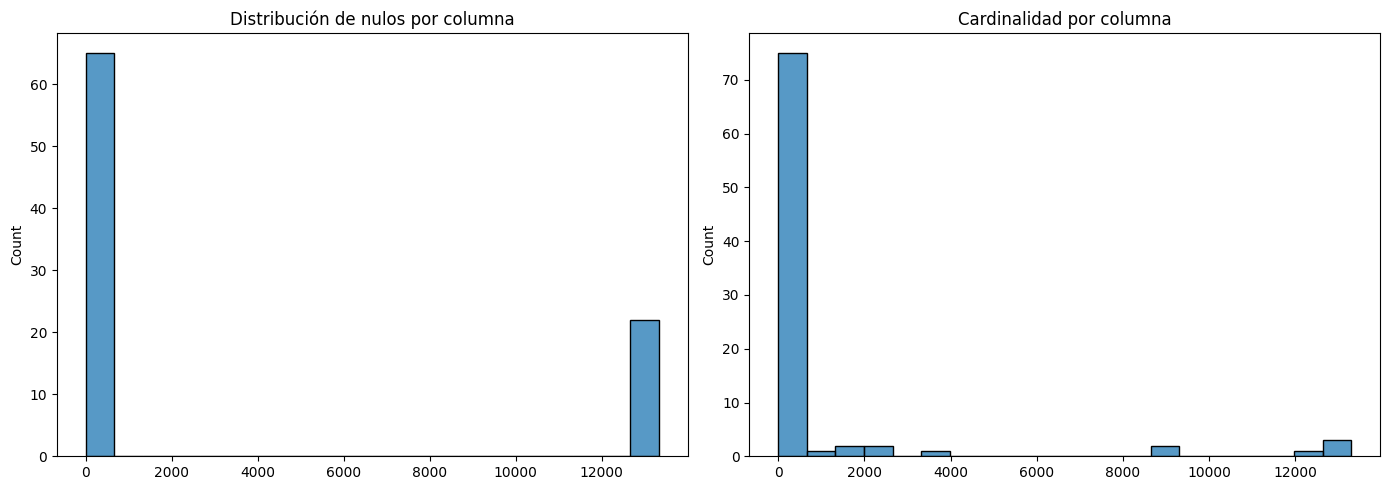

2026-05-22 10:01:34,812 INFO Pandas backend loaded 2.3.3
2026-05-22 10:01:34,824 INFO Numpy backend loaded 2.2.6
2026-05-22 10:01:34,826 INFO Pyspark backend NOT loaded
2026-05-22 10:01:34,827 INFO Python backend loaded
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 20.69it/s]

Profile report guardado en: output\artifacts\profile_report_20260522_100118.html
Versión de profiling: 4.18.4


In [5]:
# 05. Exploración inicial y perfilado automático
# Objetivo: Obtener una vista general y automatizada del dataset
# Entradas: df_raw
# Salidas: eda_overview, profile_report
# Artefactos: eda_overview.json, profile_report.html

import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Helper para serialización segura
from typing import Any

def safe_json(obj: Any):
    import numpy as np
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    elif isinstance(obj, (set,)):
        return list(obj)
    elif isinstance(obj, (bytes,)):
        return obj.decode()
    elif hasattr(obj, 'isoformat'):
        return obj.isoformat()
    return str(obj)

# Exploración inicial
eda_overview = {
    'shape': df_raw.shape,
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'nulls': df_raw.isnull().sum().to_dict(),
    'nulls_pct': (df_raw.isnull().mean()*100).round(2).to_dict(),
    'n_unique': df_raw.nunique().to_dict(),
    'memory_MB': round(df_raw.memory_usage(deep=True).sum() / 1024**2, 2),
}

# Validación de tamaño esperado
assert eda_overview['shape'][0] > 0, "El DataFrame está vacío"

# Guardar resumen EDA
eda_overview_path = ARTIFACTS_DIR / f"eda_overview_{RUN_ID}.json"
with open(eda_overview_path, "w", encoding="utf-8") as f:
    json.dump(eda_overview, f, indent=2, default=safe_json)
print(f"EDA overview guardado en: {eda_overview_path}")

# Visualizaciones básicas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_raw.isnull().sum(), ax=axes[0], bins=20)
axes[0].set_title('Distribución de nulos por columna')
sns.histplot(df_raw.nunique(), ax=axes[1], bins=20)
axes[1].set_title('Cardinalidad por columna')
plt.tight_layout()
plt.show()

# Perfilado automático (usando pandas-profiling o ydata-profiling)
try:
    import ydata_profiling as profiling
    profile_report = profiling.ProfileReport(df_raw, title="Profile Report", minimal=True)
    profile_report_path = ARTIFACTS_DIR / f"profile_report_{RUN_ID}.html"
    profile_report.to_file(profile_report_path)
    print(f"Profile report guardado en: {profile_report_path}")
    print(f"Versión de profiling: {profiling.__version__}")
except ImportError:
    print("ydata_profiling no está instalado. Instala con: pip install ydata-profiling")
    profile_report = None

# Helper para modularización
# def run_profiling(df):
#     ... # Implementar lógica de profiling modular aquí


## 06. Limpieza de datos y estandarizacion
- Nombre exacto de la seccion: Limpieza de datos y estandarizacion
- Objetivo tecnico: Corregir nulos, duplicados y tipos para un dataset limpio
- Subsecciones / bloques: Limpieza de datos; Manejo de nulos; Manejo de duplicados; Conversion de tipos; Estandarizacion
- Tipo de codigo: Imputacion, filtros, cast de tipos, normalizacion
- Datos entran: `df_raw`
- Datos salen: `df_clean`
- Visualizaciones: Antes/despues de nulos y duplicados
- Metricas: % nulos por columna, filas removidas
- Validaciones: Tipos esperados, integridad de clave
- Transformaciones: Imputacion, drop duplicates, renombrado columnas
- Errores a controlar: Sobre-limpieza, perdida de target
- Resultados a guardar: `cleaning_log.csv`
- Artefactos a exportar: `df_clean.parquet`
- Variables sugeridas: `df_clean`, `null_report`
- Checkpoint / cache: Guardar `df_clean` al cerrar la etapa
- Notas de modularizacion: Funcion `clean_data(df)`
- Reproducibilidad: Loggear reglas de limpieza
- Placeholder: agregar codigo en la celda inferior para limpieza

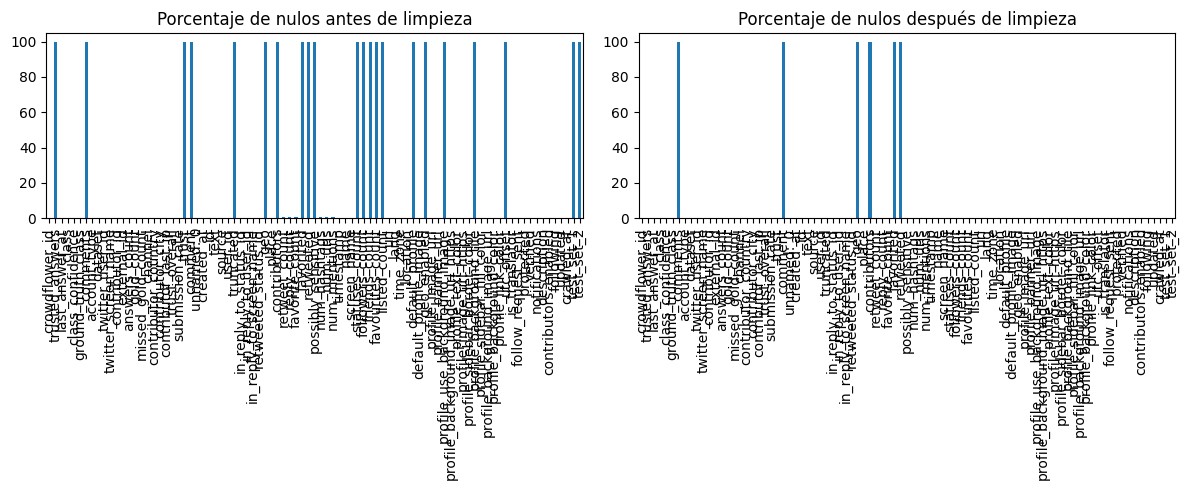

Limpieza completada. Filas finales: 13331


In [6]:
# 06. Limpieza de datos y estandarizacion
# Objetivo: Corregir nulos, duplicados y tipos para un dataset limpio
# Entradas: df_raw
# Salidas: df_clean, null_report
# Artefactos: df_clean.parquet, cleaning_log.csv

import pandas as pd
import numpy as np
import logging

# --- Helper de limpieza modular
def clean_data(df):
    cleaning_log = []
    df_clean = df.copy()
    # 1. Reporte inicial de nulos
    null_report = df_clean.isnull().mean().round(4) * 100
    cleaning_log.append({'accion': 'reporte_nulos_inicial', 'null_pct': null_report.to_dict()})
    # 2. Imputación básica: nulos numéricos a mediana, nulos string a ""
    for col in df_clean.columns:
        if df_clean[col].dtype in [np.float64, np.int64]:
            n_null = df_clean[col].isnull().sum()
            if n_null > 0:
                mediana = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(mediana)
                cleaning_log.append({'accion': 'imputacion_mediana', 'columna': col, 'valor': mediana, 'nulos_corregidos': int(n_null)})
        elif df_clean[col].dtype == object:
            n_null = df_clean[col].isnull().sum()
            if n_null > 0:
                df_clean[col] = df_clean[col].fillna("")
                cleaning_log.append({'accion': 'imputacion_vacio', 'columna': col, 'nulos_corregidos': int(n_null)})
    # 3. Remover duplicados
    n_dupes = df_clean.duplicated().sum()
    if n_dupes > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
        cleaning_log.append({'accion': 'remover_duplicados', 'filas_removidas': int(n_dupes)})
    # 4. Conversión de tipos (ejemplo: columnas numéricas mal tipadas)
    for col in df_clean.columns:
        if df_clean[col].dtype == object:
            try:
                df_clean[col] = pd.to_numeric(df_clean[col])
                cleaning_log.append({'accion': 'cast_a_numerico', 'columna': col})
            except Exception:
                pass
    # 5. Estandarización de nombres de columnas
    old_cols = list(df_clean.columns)
    df_clean.columns = [c.strip().lower().replace(' ', '_') for c in df_clean.columns]
    cleaning_log.append({'accion': 'estandarizar_columnas', 'antes': old_cols, 'despues': list(df_clean.columns)})
    # 6. Reporte final de nulos
    null_report_final = df_clean.isnull().mean().round(4) * 100
    cleaning_log.append({'accion': 'reporte_nulos_final', 'null_pct': null_report_final.to_dict()})
    return df_clean, null_report, cleaning_log

# --- Aplicar limpieza y guardar artefactos
df_clean, null_report, cleaning_log = clean_data(df_raw)

# Guardar log de limpieza
pd.DataFrame(cleaning_log).to_csv('cleaning_log.csv', index=False)
# Guardar dataset limpio
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_clean.to_parquet('output/df_clean.parquet', index=False)

# Visualización antes/después de nulos y duplicados
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
null_report.plot(kind='bar', ax=axes[0], title='Porcentaje de nulos antes de limpieza')
df_clean.isnull().mean().round(4).mul(100).plot(kind='bar', ax=axes[1], title='Porcentaje de nulos después de limpieza')
plt.tight_layout()
plt.show()

print(f"Limpieza completada. Filas finales: {df_clean.shape[0]}")


## 07. Parsing temporal y normalizacion de timestamps
- Nombre exacto de la seccion: Parsing temporal y normalizacion de timestamps
- Objetivo tecnico: Unificar fechas y derivar columnas temporales confiables
- Subsecciones / bloques: Parsing temporal; Normalizacion de zona horaria; Derivacion de features base
- Tipo de codigo: Parsing datetime, time zone handling, feature derivation
- Datos entran: `df_clean`
- Datos salen: `df_time`
- Visualizaciones: Series temporales de actividad
- Metricas: Tasa de parseo correcto, % fechas invalidas
- Validaciones: Rangos de fechas, timezone consistente
- Transformaciones: Cast a datetime, bins temporales
- Errores a controlar: Formatos mixtos, timezone perdida
- Resultados a guardar: `time_parse_report.json`
- Artefactos a exportar: `df_time.parquet`
- Variables sugeridas: `time_cols`, `df_time`
- Checkpoint / cache: Guardar dataset con timestamps normalizados
- Notas de modularizacion: Funcion `parse_time_columns(df)`
- Reproducibilidad: Loggear formato y timezone usados
- Placeholder: agregar codigo en la celda inferior para parsing

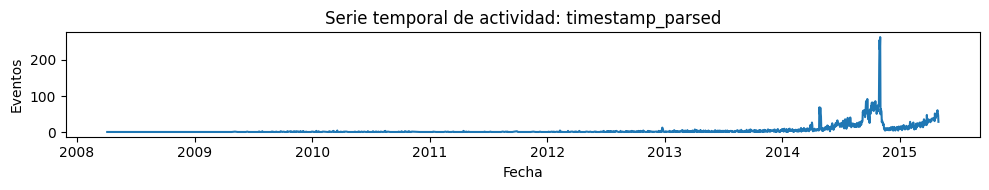

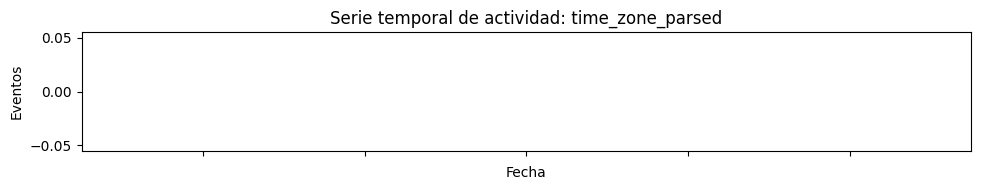

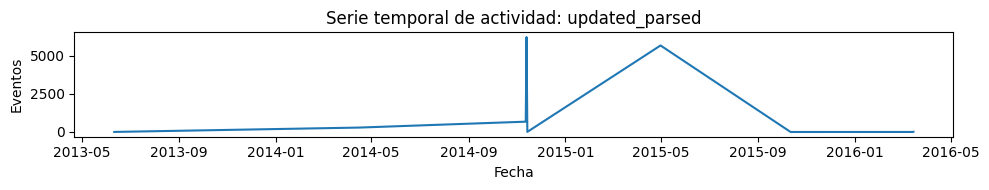

Parsing temporal completado. Columnas procesadas: ['timestamp', 'time_zone', 'updated']


In [7]:
# 07. Parsing temporal y normalizacion de timestamps
# Objetivo: Unificar fechas y derivar columnas temporales confiables
# Entradas: df_clean
# Salidas: df_time, time_parse_report
# Artefactos: df_time.parquet, time_parse_report.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helper para parsing y normalización temporal
def parse_time_columns(df, time_zone='UTC'):
    df_time = df.copy()
    time_cols = [col for col in df_time.columns if 'date' in col or 'time' in col or 'fecha' in col]
    parse_report = {'col': [], 'parsed_pct': [], 'invalid_pct': [], 'timezone': time_zone, 'format': 'auto'}
    for col in time_cols:
        try:
            parsed = pd.to_datetime(df_time[col], errors='coerce', utc=True)
            n_valid = parsed.notnull().sum()
            n_total = len(parsed)
            df_time[col + '_parsed'] = parsed.dt.tz_convert(time_zone) if parsed.dt.tz else parsed
            parse_report['col'].append(col)
            parse_report['parsed_pct'].append(round(100 * n_valid / n_total, 2))
            parse_report['invalid_pct'].append(round(100 * (n_total - n_valid) / n_total, 2))
        except Exception as e:
            logging.warning(f'No se pudo parsear {col}: {e}')
            parse_report['col'].append(col)
            parse_report['parsed_pct'].append(0.0)
            parse_report['invalid_pct'].append(100.0)
    # Derivar features base si hay columnas parseadas
    for col in [c for c in df_time.columns if c.endswith('_parsed')]:
        df_time[col + '_year'] = df_time[col].dt.year
        df_time[col + '_month'] = df_time[col].dt.month
        df_time[col + '_day'] = df_time[col].dt.day
        df_time[col + '_hour'] = df_time[col].dt.hour
        df_time[col + '_weekday'] = df_time[col].dt.weekday
    return df_time, time_cols, parse_report

# --- Aplicar parsing temporal y guardar artefactos
df_time, time_cols, time_parse_report = parse_time_columns(df_clean, time_zone='UTC')

# Guardar reporte de parseo
time_parse_report_path = 'time_parse_report.json'
with open(time_parse_report_path, 'w', encoding='utf-8') as f:
    json.dump(time_parse_report, f, indent=2)
# Guardar dataset con timestamps normalizados
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_time.to_parquet('output/df_time.parquet', index=False)

# Visualización: series temporales de actividad (si hay columnas parseadas)
import matplotlib.pyplot as plt
parsed_cols = [c for c in df_time.columns if c.endswith('_parsed')]
if parsed_cols:
    for col in parsed_cols:
        plt.figure(figsize=(10,2))
        df_time[col].dropna().dt.date.value_counts().sort_index().plot()
        plt.title(f'Serie temporal de actividad: {col}')
        plt.xlabel('Fecha')
        plt.ylabel('Eventos')
        plt.tight_layout()
        plt.show()
else:
    print('No se encontraron columnas temporales parseadas.')

print(f"Parsing temporal completado. Columnas procesadas: {time_cols}")



## 08. Extracción y normalización de variables categóricas

**Objetivo técnico:** Unificar, limpiar y codificar variables categóricas clave para análisis y modelado.

- **Subsecciones / bloques:** Extracción de variables categóricas; limpieza y normalización; agrupación de categorías poco frecuentes; codificación básica.
- **Tipo de código:** Limpieza de strings, reemplazo de nulos, agrupación de categorías, reporte de cardinalidad y frecuencia.
- **Datos entran:** `df_time`
- **Datos salen:** `df_cat`, `cat_cols`, `cat_report`
- **Visualizaciones:** Distribución de las principales categorías por variable
- **Métricas:** Cardinalidad, top categorías, frecuencia de nulos/otros
- **Validaciones:** Cardinalidad esperada, presencia de valores vacíos
- **Transformaciones:** Limpieza de strings, agrupación de categorías raras, reemplazo de nulos
- **Errores a controlar:** Pérdida de información relevante, sobre-agregación
- **Resultados a guardar:** `cat_report.json`
- **Artefactos a exportar:** `df_cat.parquet`
- **Variables sugeridas:** `df_cat`, `cat_cols`, `cat_report`
- **Checkpoint / cache:** Guardar dataset categórico procesado
- **Notas de modularización:** Función `process_categorical_columns(df)`
- **Reproducibilidad:** Loggear reglas de limpieza y agrupación
- **Placeholder:** El código de procesamiento categórico se encuentra en la celda inferior


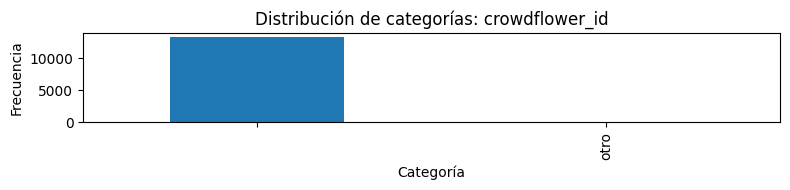

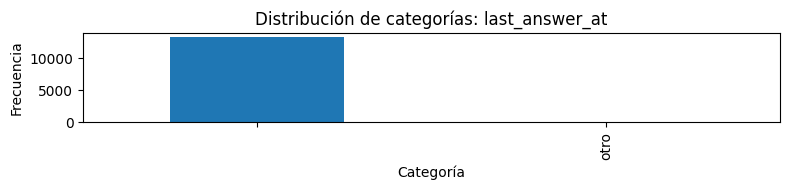

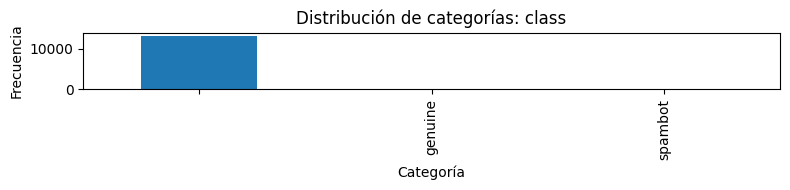

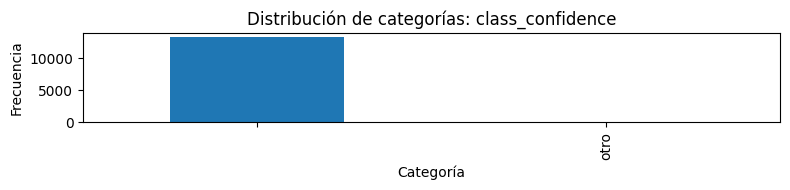

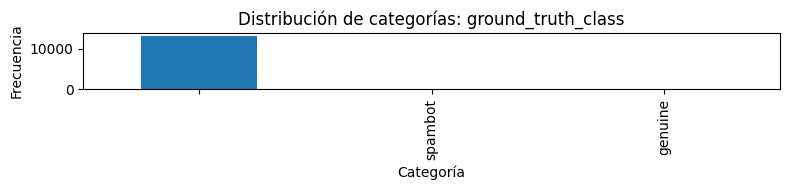

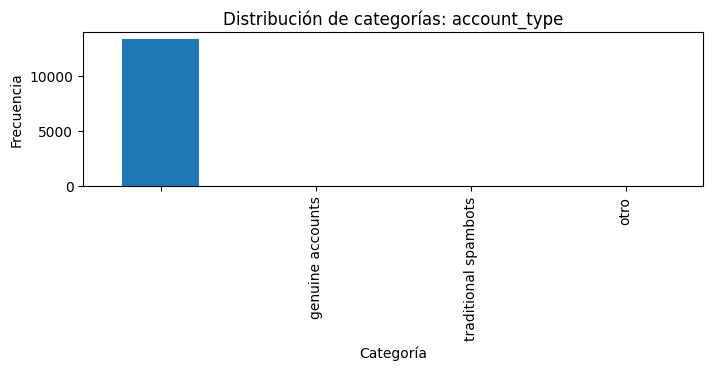

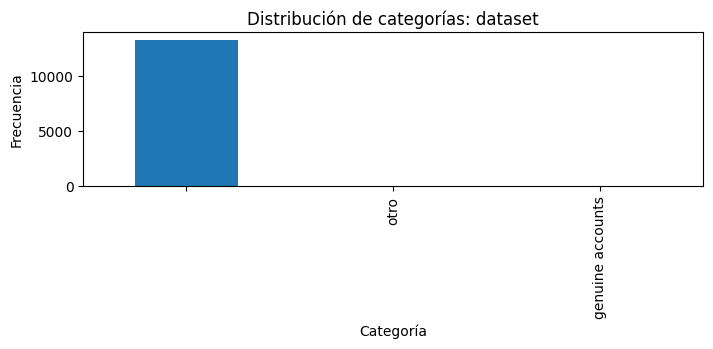

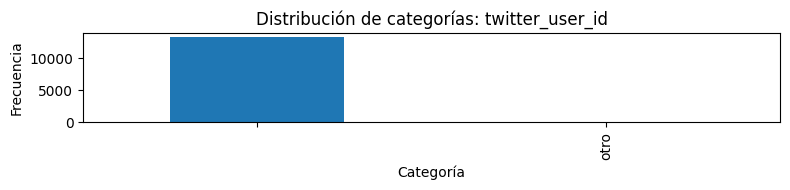

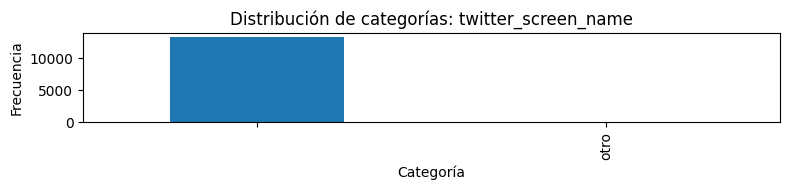

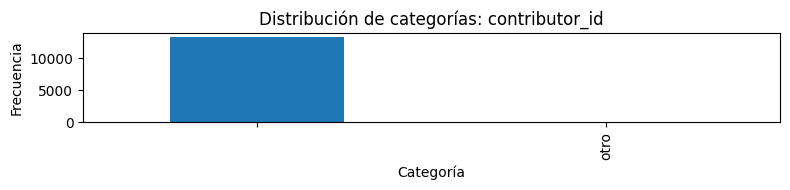

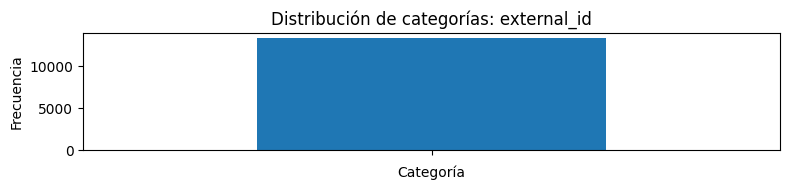

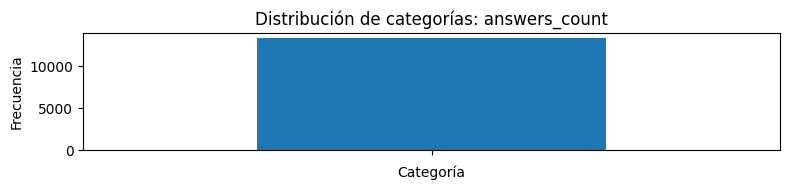

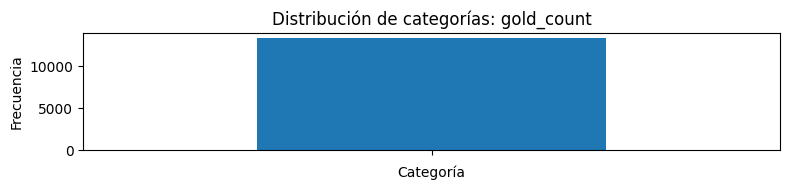

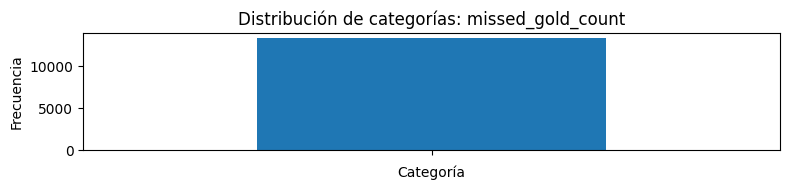

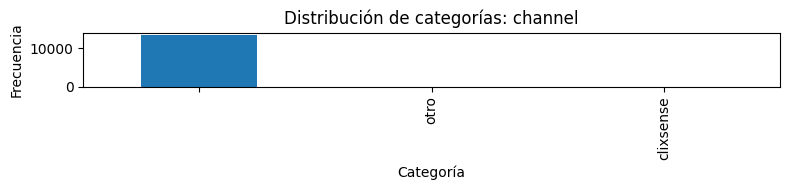

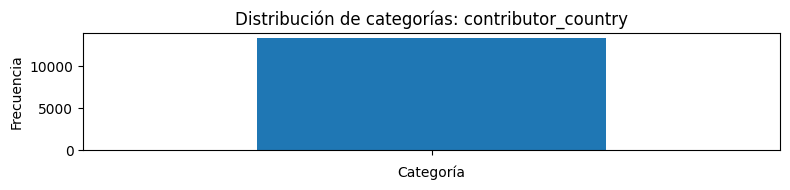

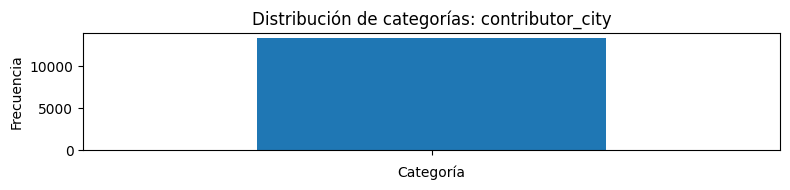

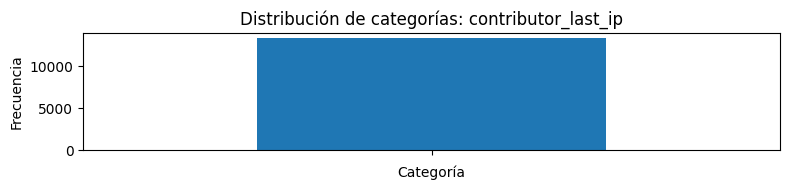

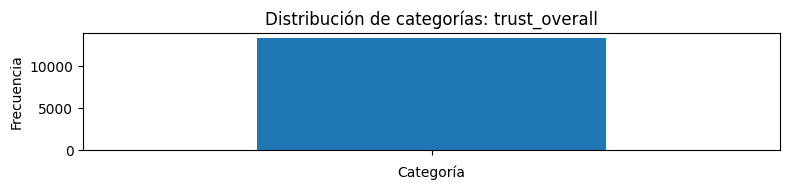

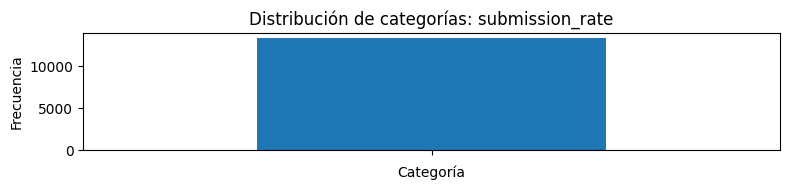

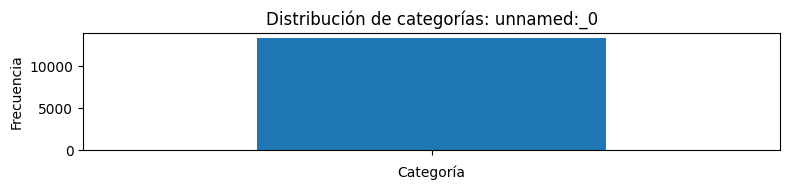

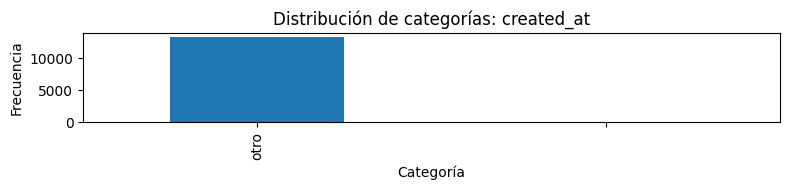

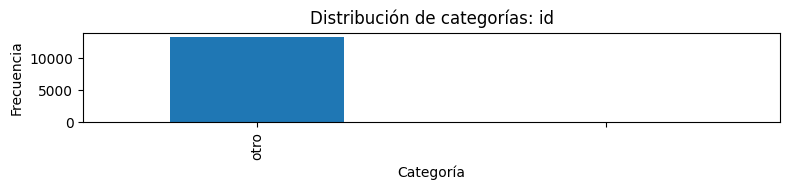

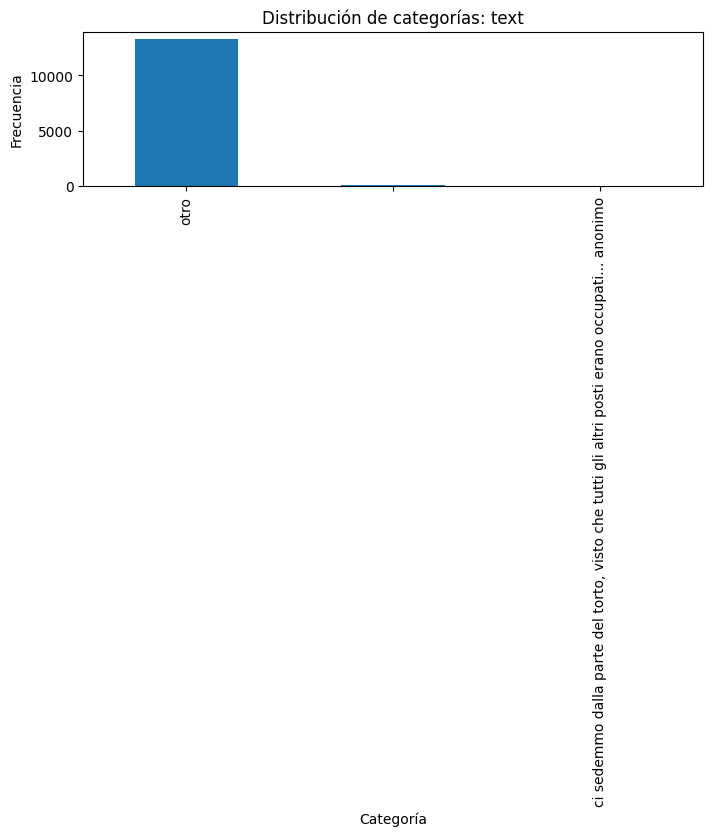

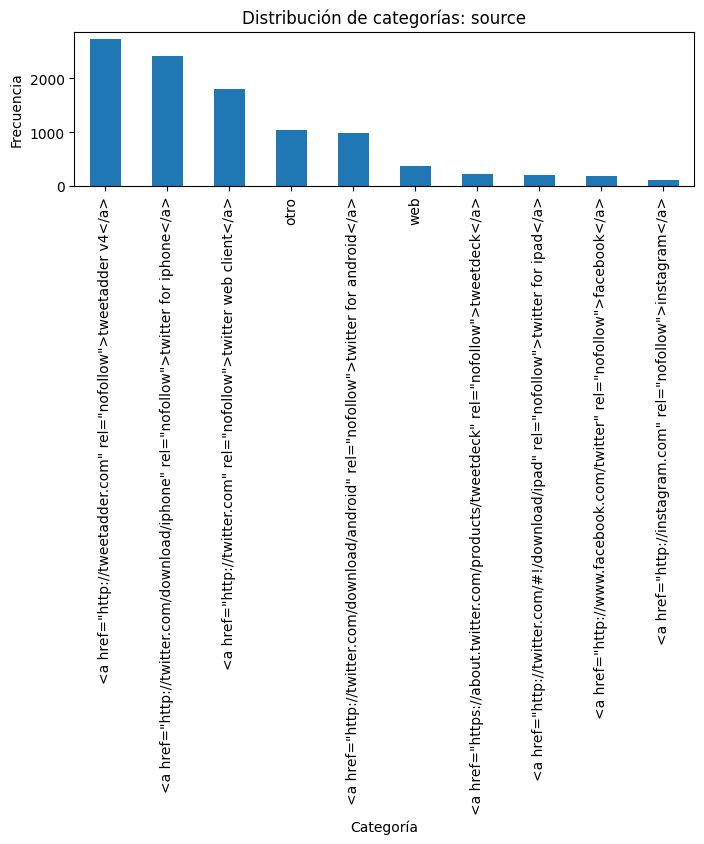

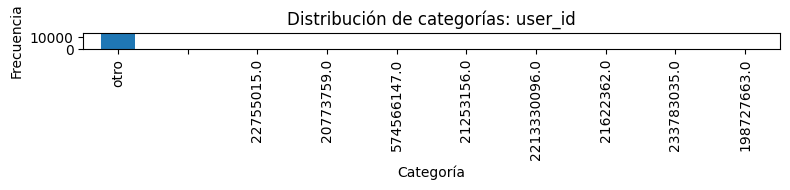

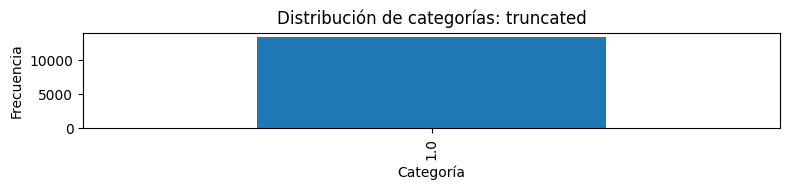

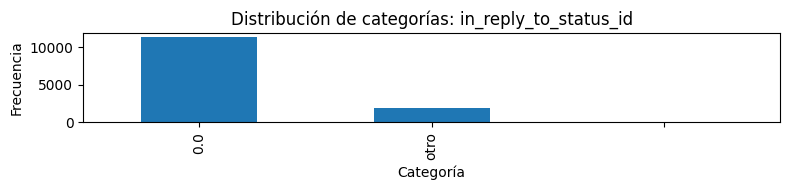

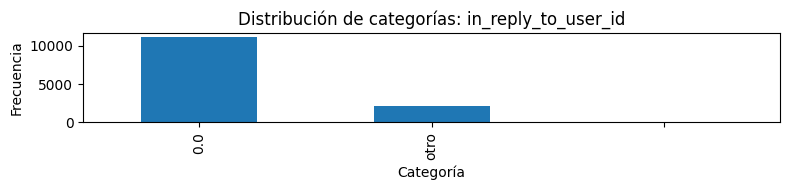

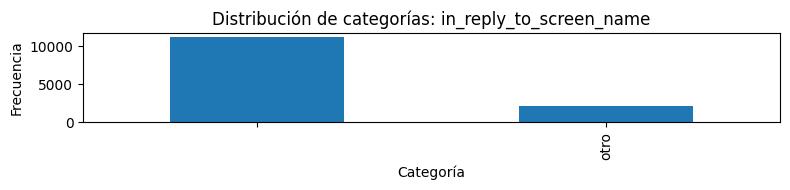

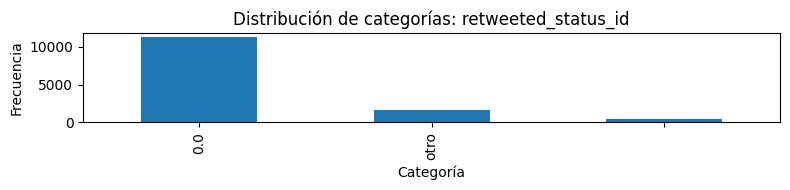

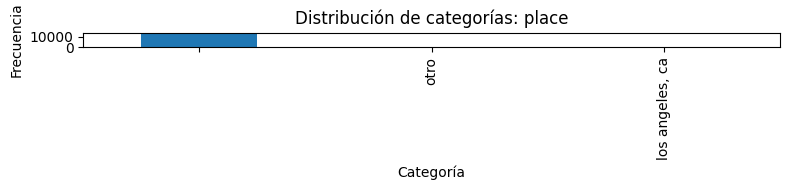

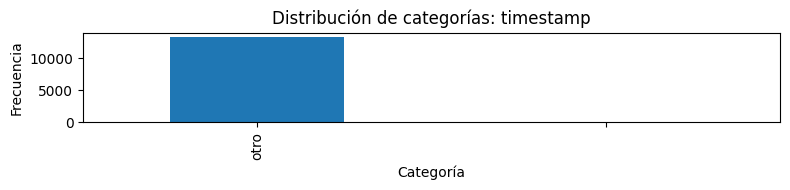

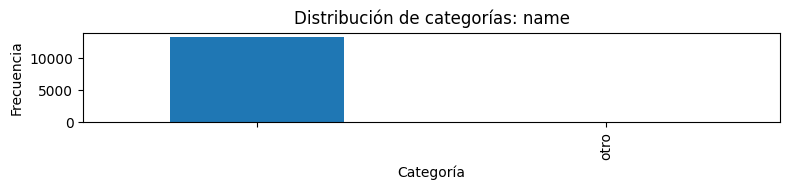

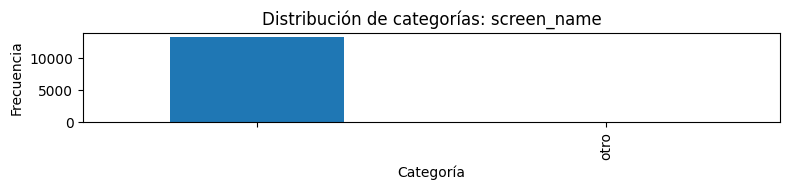

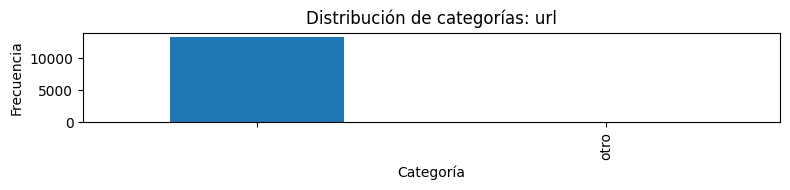

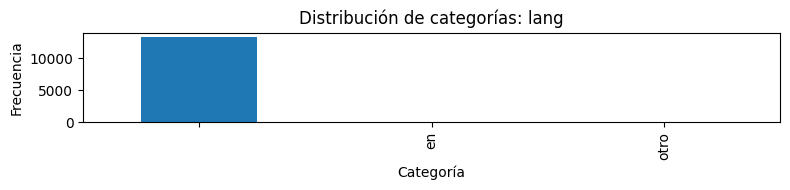

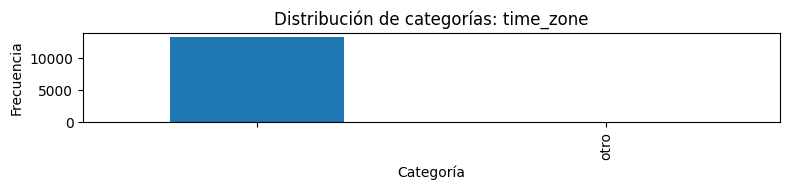

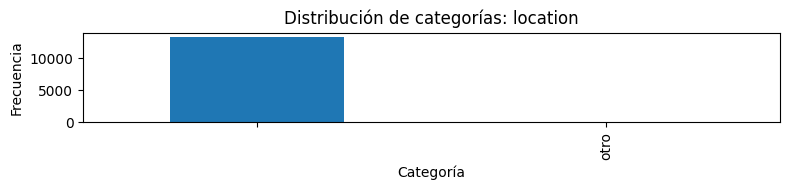

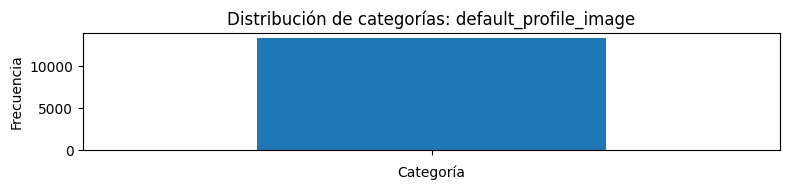

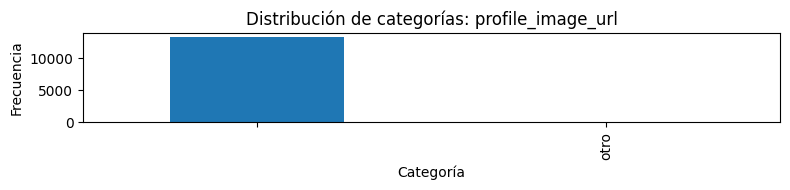

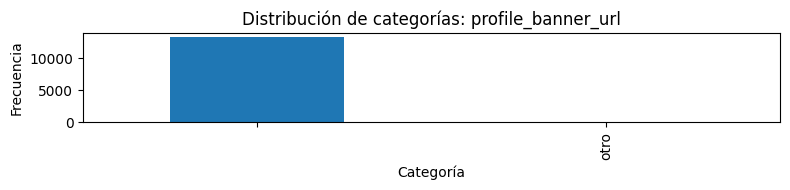

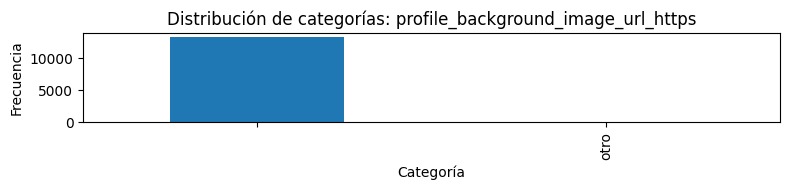

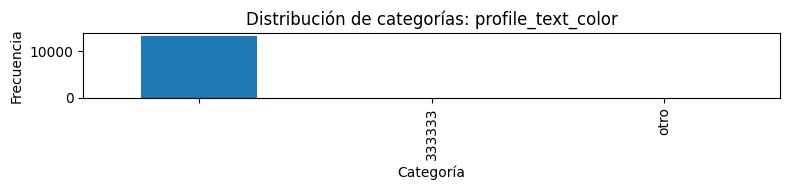

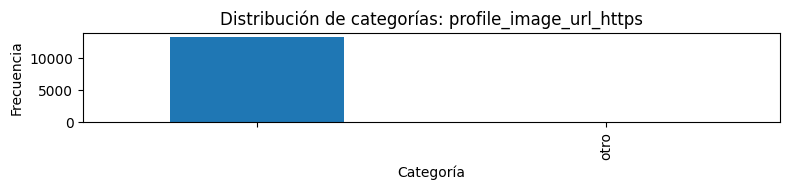

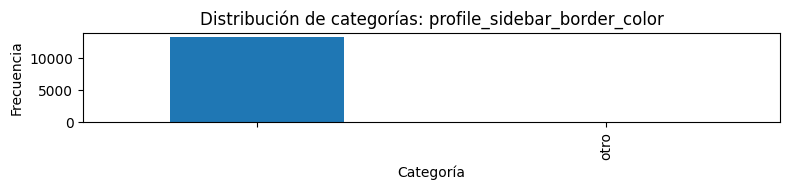

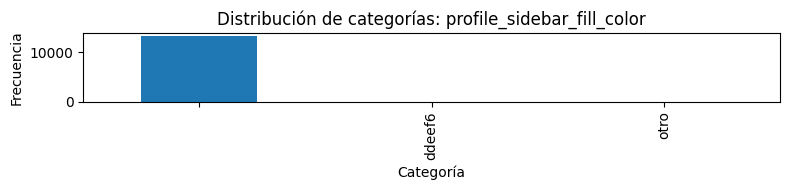

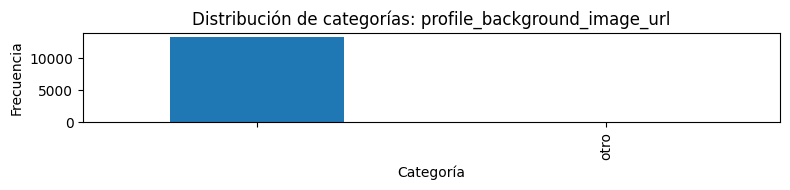

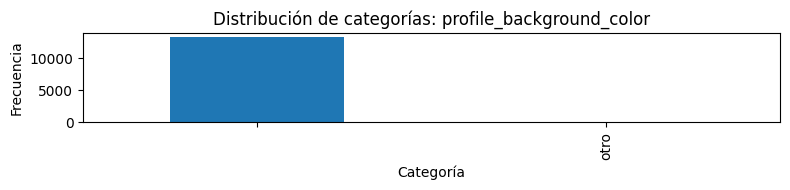

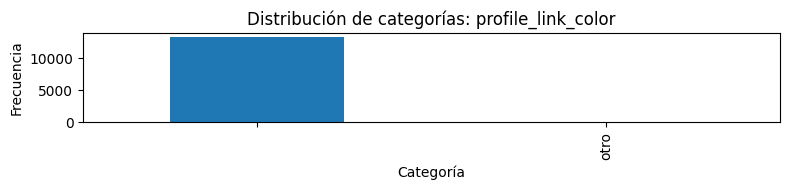

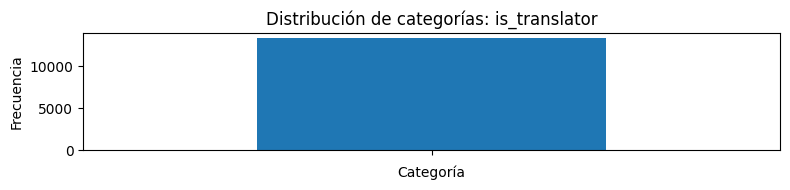

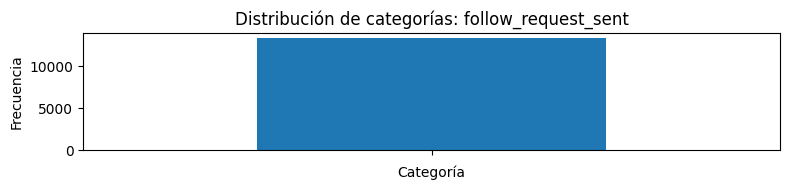

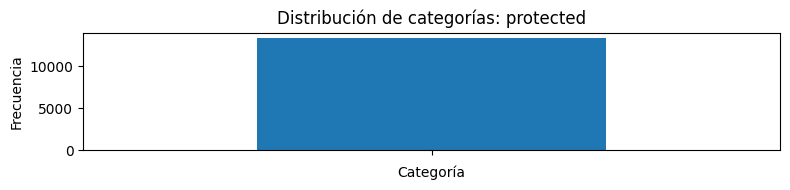

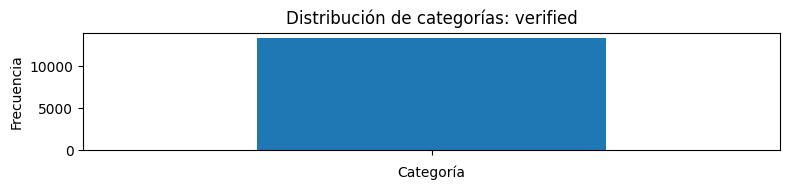

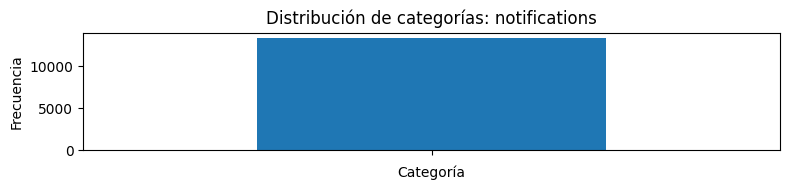

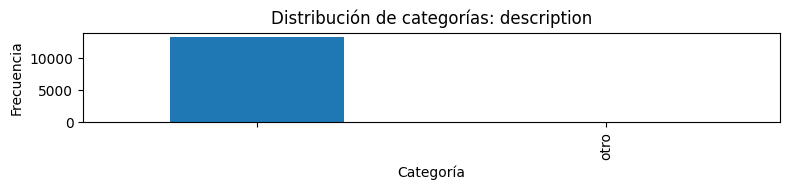

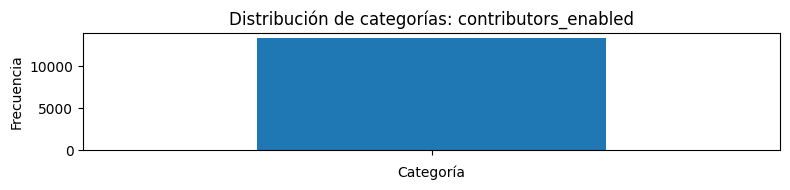

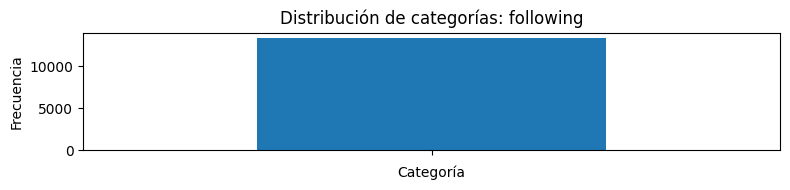

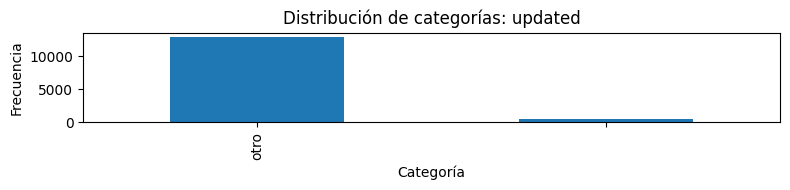

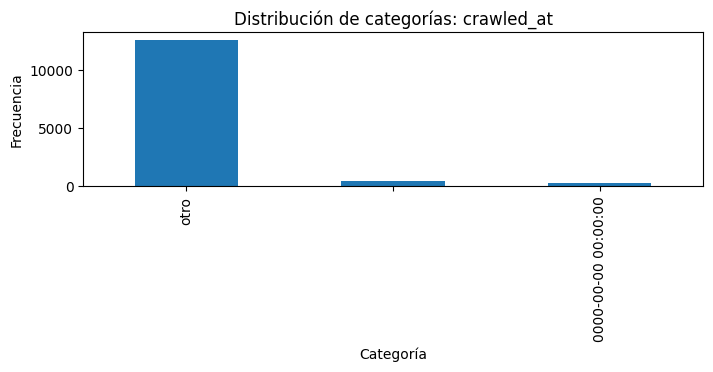

Procesamiento categórico completado. Columnas procesadas: ['crowdflower_id', 'last_answer_at', 'class', 'class_confidence', 'ground_truth_class', 'account_type', 'dataset', 'twitter_user_id', 'twitter_screen_name', 'contributor_id', 'external_id', 'answers_count', 'gold_count', 'missed_gold_count', 'channel', 'contributor_country', 'contributor_city', 'contributor_last_ip', 'trust_overall', 'submission_rate', 'unnamed:_0', 'created_at', 'id', 'text', 'source', 'user_id', 'truncated', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'retweeted_status_id', 'place', 'timestamp', 'name', 'screen_name', 'url', 'lang', 'time_zone', 'location', 'default_profile_image', 'profile_image_url', 'profile_banner_url', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'is_translator', 'follow_requ

In [8]:
# 08. Extracción y normalización de variables categóricas
# Objetivo: Unificar, limpiar y codificar variables categóricas clave para análisis y modelado
# Entradas: df_time
# Salidas: df_cat, cat_report
# Artefactos: df_cat.parquet, cat_report.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helper para extracción y limpieza de variables categóricas
def process_categorical_columns(df, min_freq=10):
    df_cat = df.copy()
    cat_cols = [col for col in df_cat.columns if df_cat[col].dtype == object or 'cat' in col or 'label' in col]
    cat_report = {'col': [], 'n_unique': [], 'top_values': [], 'n_invalid': []}
    for col in cat_cols:
        # Limpieza básica: quitar espacios, pasar a minúsculas, reemplazar nulos
        df_cat[col] = df_cat[col].astype(str).str.strip().str.lower().replace({'nan': '', 'none': ''})
        # Agrupar categorías poco frecuentes
        value_counts = df_cat[col].value_counts()
        rare = value_counts[value_counts < min_freq].index
        df_cat[col] = df_cat[col].replace(rare, 'otro')
        cat_report['col'].append(col)
        cat_report['n_unique'].append(df_cat[col].nunique())
        cat_report['top_values'].append(df_cat[col].value_counts().head(5).to_dict())
        cat_report['n_invalid'].append((df_cat[col] == '').sum())
    return df_cat, cat_cols, cat_report

# --- Aplicar procesamiento categórico y guardar artefactos
df_cat, cat_cols, cat_report = process_categorical_columns(df_time)

# Guardar reporte de categorías (serializar tipos no nativos de JSON)
cat_report_path = 'cat_report.json'
with open(cat_report_path, 'w', encoding='utf-8') as f:
    # convert_types_for_json defined earlier in the notebook (cell 8)
    json.dump(convert_types_for_json(cat_report), f, indent=2)

# Guardar dataset con variables categóricas procesadas
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_cat.to_parquet('output/df_cat.parquet', index=False)

# Visualización: distribución de las principales categorías
import matplotlib.pyplot as plt
for col in cat_cols:
    plt.figure(figsize=(8,2))
    df_cat[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Distribución de categorías: {col}')
    plt.xlabel('Categoría')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

print(f"Procesamiento categórico completado. Columnas procesadas: {cat_cols}")

## 09. Extraccion de features conductuales
- Nombre exacto de la seccion: Extraccion de features conductuales
- Objetivo tecnico: Generar features de comportamiento y de interaccion bot/humano
- Subsecciones / bloques: Features de actividad; Metricas de inmersion/interaccion; Agregaciones por usuario
- Tipo de codigo: Aggregations, ratios, ventanas de tiempo
- Datos entran: `df_time` y/o `df_text`
- Datos salen: `feat_behavioral`
- Visualizaciones: Distribuciones de ratios y tasas de actividad
- Metricas: Posts por dia, ratio RT, ratio follower/following
- Validaciones: Rango de ratios, divisiones por cero
- Transformaciones: Agregacion por usuario, normalizacion de tasas
- Errores a controlar: Sesgo por usuarios inactivos
- Resultados a guardar: `features_behavioral.parquet`
- Artefactos a exportar: `behavioral_feature_defs.json`
- Variables sugeridas: `feat_behavioral`, `user_id_col`
- Checkpoint / cache: Guardar features conductuales
- Notas de modularizacion: Funcion `build_behavioral_features(df)`
- Reproducibilidad: Fijar ventanas temporales y reglas de agregacion
- Placeholder: agregar codigo en la celda inferior para features conductuales

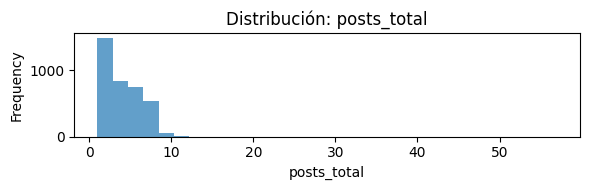

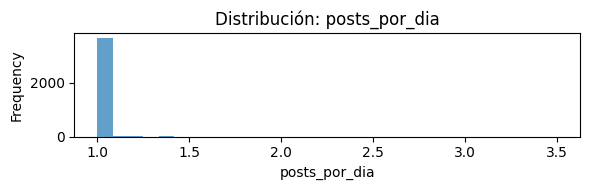

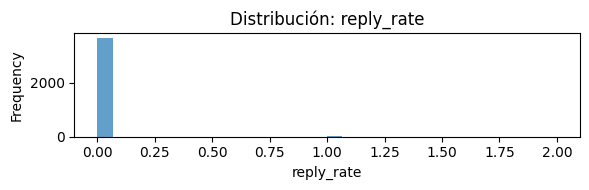

Features conductuales generados para 3684 usuarios.


In [9]:
# 09. Extraccion de features conductuales
# Objetivo: Generar features de comportamiento y de interaccion bot/humano
# Entradas: df_time (y/o df_text)
# Salidas: feat_behavioral, user_id_col
# Artefactos: features_behavioral.parquet, behavioral_feature_defs.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helper para extracción de features conductuales
def build_behavioral_features(df, user_id_col='user_id', time_col=None):
    feat_defs = []
    # Si no se especifica columna temporal, buscar una
    if not time_col:
        time_col = next((c for c in df.columns if c.endswith('_parsed')), None)
    if not time_col or user_id_col not in df.columns:
        raise ValueError('No se encontró columna temporal o de usuario')
    # Agregaciones por usuario
    grp = df.groupby(user_id_col)
    features = pd.DataFrame()
    features['posts_total'] = grp.size()
    features['posts_por_dia'] = grp[time_col].apply(lambda x: x.dt.date.nunique() if x.notnull().any() else 0)
    features['posts_por_dia'] = features['posts_total'] / features['posts_por_dia'].replace(0, np.nan)
    feat_defs.append({'feature': 'posts_por_dia', 'desc': 'Promedio de posts por día'})
    # Ratio RT (si existe columna retweet)
    if 'is_retweet' in df.columns:
        features['ratio_rt'] = grp['is_retweet'].mean()
        feat_defs.append({'feature': 'ratio_rt', 'desc': 'Proporción de retweets'})
    # Ratio follower/following (si existen)
    if 'followers_count' in df.columns and 'following_count' in df.columns:
        features['ratio_follower_following'] = grp['followers_count'].mean() / grp['following_count'].replace(0, np.nan).mean()
        feat_defs.append({'feature': 'ratio_follower_following', 'desc': 'Ratio promedio followers/following'})
    # Otras métricas de interacción
    if 'reply_count' in df.columns:
        features['reply_rate'] = grp['reply_count'].mean() / features['posts_total']
        feat_defs.append({'feature': 'reply_rate', 'desc': 'Tasa de respuestas por post'})
    # Normalización de tasas
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    features.reset_index(inplace=True)
    return features, feat_defs

# --- Aplicar extracción de features conductuales y guardar artefactos
feat_behavioral, behavioral_feature_defs = build_behavioral_features(df_time, user_id_col='user_id')

# Guardar definiciones y dataset
with open('behavioral_feature_defs.json', 'w', encoding='utf-8') as f:
    json.dump(behavioral_feature_defs, f, indent=2)
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
feat_behavioral.to_parquet('output/features_behavioral.parquet', index=False)

# Visualización: distribuciones de ratios y tasas
import matplotlib.pyplot as plt
for col in feat_behavioral.columns:
    if col not in ['user_id']:
        plt.figure(figsize=(6,2))
        feat_behavioral[col].plot(kind='hist', bins=30, alpha=0.7)
        plt.title(f'Distribución: {col}')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

print(f"Features conductuales generados para {feat_behavioral.shape[0]} usuarios.")


## 10. Extraccion de features temporales
- Nombre exacto de la seccion: Extraccion de features temporales
- Objetivo tecnico: Capturar patrones temporales y ritmos de actividad
- Subsecciones / bloques: Patrones diarios/semanales; Entropia temporal; Rachas y bursts
- Tipo de codigo: Time series features, ventanas deslizantes
- Datos entran: `df_time`
- Datos salen: `feat_temporal`
- Visualizaciones: Heatmaps de actividad, series temporales
- Metricas: Entropia de tiempos, regularidad, burstiness
- Validaciones: Ventanas temporales validas
- Transformaciones: Binning temporal, agregaciones
- Errores a controlar: Timezone inconsistente, gaps
- Resultados a guardar: `features_temporal.parquet`
- Artefactos a exportar: `temporal_feature_defs.json`
- Variables sugeridas: `feat_temporal`, `time_bins`
- Checkpoint / cache: Guardar features temporales
- Notas de modularizacion: Funcion `build_temporal_features(df)`
- Reproducibilidad: Registrar granulosidad temporal usada
- Placeholder: agregar codigo en la celda inferior para features temporales

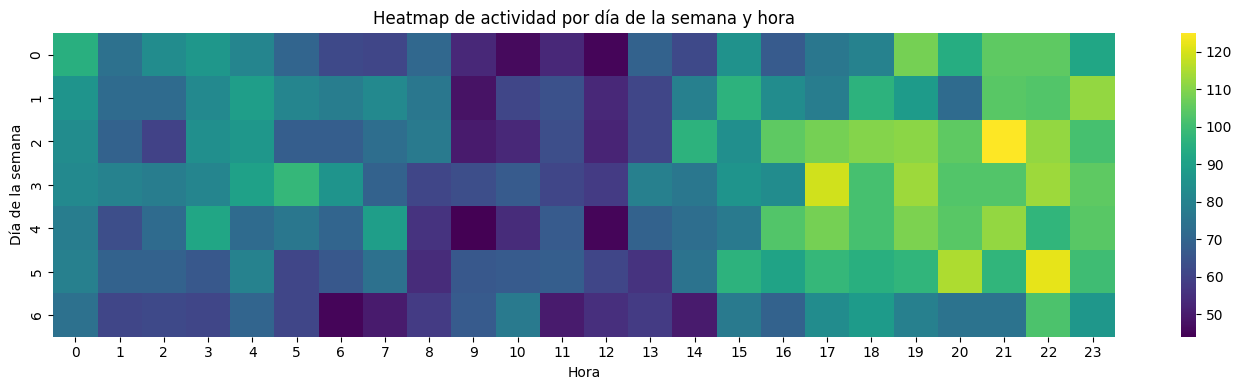

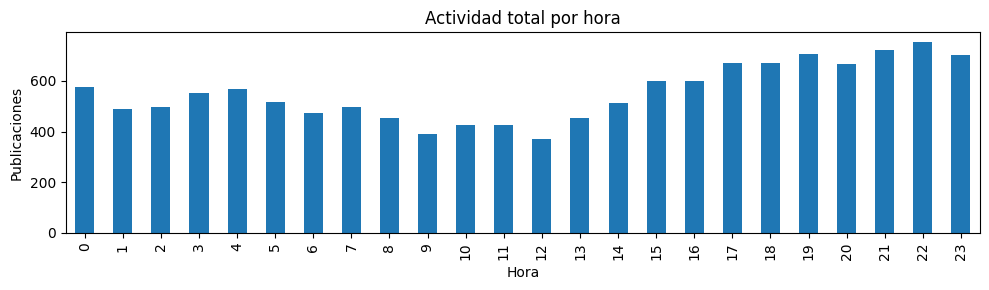

Features temporales generados para 3683 usuarios.
Columna temporal usada: timestamp_parsed


In [10]:
# 10. Extraccion de features temporales
# Objetivo: Capturar patrones temporales y ritmos de actividad
# Entradas: df_time
# Salidas: feat_temporal, time_bins
# Artefactos: features_temporal.parquet, temporal_feature_defs.json

def _shannon_entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())

def build_temporal_features(df, user_id_col='user_id', time_col=None):
    df_tmp = df.copy()

    # Selección robusta de columna temporal
    if time_col is None:
        preferred = ['timestamp_parsed', 'created_at_parsed', 'updated_parsed']
        time_col = next((c for c in preferred if c in df_tmp.columns), None)
        if time_col is None:
            time_col = next((c for c in df_tmp.columns if c.endswith('_parsed')), None)

    if time_col is None or user_id_col not in df_tmp.columns:
        raise ValueError('No se encontró la columna temporal o la columna de usuario.')

    # Limpieza mínima
    df_tmp[user_id_col] = df_tmp[user_id_col].astype(str).str.strip()
    df_tmp[user_id_col] = df_tmp[user_id_col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    df_tmp[time_col] = pd.to_datetime(df_tmp[time_col], errors='coerce', utc=True)
    df_tmp = df_tmp.dropna(subset=[user_id_col, time_col]).copy()

    # Variables temporales base
    df_tmp['hour'] = df_tmp[time_col].dt.hour
    df_tmp['weekday'] = df_tmp[time_col].dt.weekday
    df_tmp['date'] = df_tmp[time_col].dt.date
    df_tmp['is_weekend'] = df_tmp['weekday'].isin([5, 6]).astype(int)

    feature_defs = [
        {'feature': 'posts_total', 'desc': 'Número total de publicaciones por usuario'},
        {'feature': 'active_days', 'desc': 'Cantidad de días distintos con actividad'},
        {'feature': 'span_days', 'desc': 'Ventana temporal entre primera y última publicación'},
        {'feature': 'posts_per_active_day', 'desc': 'Promedio de publicaciones por día activo'},
        {'feature': 'posts_per_span_day', 'desc': 'Promedio de publicaciones por día en la ventana total'},
        {'feature': 'mean_interarrival_hours', 'desc': 'Tiempo medio entre publicaciones'},
        {'feature': 'std_interarrival_hours', 'desc': 'Desviación estándar entre publicaciones'},
        {'feature': 'burstiness', 'desc': 'Medida de rachas/bursts temporales'},
        {'feature': 'hour_entropy', 'desc': 'Entropía de actividad por hora'},
        {'feature': 'weekday_entropy', 'desc': 'Entropía de actividad por día de la semana'},
        {'feature': 'peak_hour_share', 'desc': 'Proporción de actividad en la hora más frecuente'},
        {'feature': 'peak_weekday_share', 'desc': 'Proporción de actividad en el día más frecuente'},
        {'feature': 'weekend_ratio', 'desc': 'Proporción de publicaciones en fin de semana'},
        {'feature': 'active_hours', 'desc': 'Cantidad de horas distintas con actividad'},
        {'feature': 'active_weekdays', 'desc': 'Cantidad de días de semana distintos con actividad'},
    ]

    rows = []
    grouped = df_tmp.sort_values([user_id_col, time_col]).groupby(user_id_col, sort=False)

    for user_id, g in grouped:
        ts = g[time_col].sort_values()
        n_posts = int(len(g))
        active_days = int(g['date'].nunique())

        if n_posts > 1:
            diffs_hours = ts.diff().dropna().dt.total_seconds() / 3600.0
            mean_iat = float(diffs_hours.mean()) if len(diffs_hours) else 0.0
            std_iat = float(diffs_hours.std()) if len(diffs_hours) else 0.0
        else:
            mean_iat = 0.0
            std_iat = 0.0

        span_days = float((ts.max() - ts.min()).total_seconds() / 86400.0) if n_posts > 1 else 0.0
        span_days = max(span_days, 0.0) + 1.0 if n_posts > 0 else 0.0

        posts_per_active_day = n_posts / active_days if active_days > 0 else 0.0
        posts_per_span_day = n_posts / span_days if span_days > 0 else 0.0

        burstiness = 0.0
        if (mean_iat + std_iat) > 0:
            burstiness = (std_iat - mean_iat) / (std_iat + mean_iat)

        hour_counts = g['hour'].value_counts().sort_index()
        weekday_counts = g['weekday'].value_counts().sort_index()

        hour_entropy = _shannon_entropy_from_counts(hour_counts.values)
        weekday_entropy = _shannon_entropy_from_counts(weekday_counts.values)

        peak_hour_share = float(hour_counts.max() / n_posts) if n_posts > 0 else 0.0
        peak_weekday_share = float(weekday_counts.max() / n_posts) if n_posts > 0 else 0.0

        weekend_ratio = float(g['is_weekend'].mean()) if n_posts > 0 else 0.0

        rows.append({
            user_id_col: user_id,
            'posts_total': n_posts,
            'active_days': active_days,
            'span_days': span_days,
            'posts_per_active_day': posts_per_active_day,
            'posts_per_span_day': posts_per_span_day,
            'mean_interarrival_hours': mean_iat,
            'std_interarrival_hours': std_iat,
            'burstiness': burstiness,
            'hour_entropy': hour_entropy,
            'weekday_entropy': weekday_entropy,
            'peak_hour_share': peak_hour_share,
            'peak_weekday_share': peak_weekday_share,
            'weekend_ratio': weekend_ratio,
            'active_hours': int(g['hour'].nunique()),
            'active_weekdays': int(g['weekday'].nunique())
        })

    feat_temporal = pd.DataFrame(rows).fillna(0)
    return feat_temporal, time_col, feature_defs

# --- Aplicar extracción de features temporales
feat_temporal, time_bins, temporal_feature_defs = build_temporal_features(df_time, user_id_col='user_id')

# --- Guardar artefactos
with open('temporal_feature_defs.json', 'w', encoding='utf-8') as f:
    json.dump(temporal_feature_defs, f, indent=2, ensure_ascii=False)

Path('output').mkdir(parents=True, exist_ok=True)
feat_temporal.to_parquet('output/features_temporal.parquet', index=False)

# --- Visualizaciones
activity_df = df_time.copy()
activity_df['timestamp_parsed'] = pd.to_datetime(activity_df.get('timestamp_parsed'), errors='coerce', utc=True)

if 'timestamp_parsed' in activity_df.columns and activity_df['timestamp_parsed'].notna().any():
    activity_df['hour'] = activity_df['timestamp_parsed'].dt.hour
    activity_df['weekday'] = activity_df['timestamp_parsed'].dt.weekday

    heatmap_data = activity_df.pivot_table(
        index='weekday',
        columns='hour',
        values='user_id',
        aggfunc='count',
        fill_value=0
    ).reindex(index=range(7), columns=range(24), fill_value=0)

    plt.figure(figsize=(14, 4))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title('Heatmap de actividad por día de la semana y hora')
    plt.xlabel('Hora')
    plt.ylabel('Día de la semana')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))
    heatmap_data.sum(axis=0).plot(kind='bar')
    plt.title('Actividad total por hora')
    plt.xlabel('Hora')
    plt.ylabel('Publicaciones')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró una columna temporal válida para graficar.')

print(f'Features temporales generados para {feat_temporal.shape[0]} usuarios.')
print(f'Columna temporal usada: {time_bins}')

## 11. Extraccion de features linguisticas y NLP
- Nombre exacto de la seccion: Extraccion de features linguisticas y NLP
- Objetivo tecnico: Construir features basadas en contenido textual
- Subsecciones / bloques: TF-IDF; N-gramas; Embeddings (placeholder)
- Tipo de codigo: Vectorizacion, embeddings, estadisticas linguisticas
- Datos entran: `df_text`, `corpus_tokens`
- Datos salen: `feat_linguistic`
- Visualizaciones: Distribucion de longitud de texto, top n-gramas
- Metricas: Diversidad lexical, polaridad promedio
- Validaciones: Dimensiones de matrices, vocabulario consistente
- Transformaciones: Vectorizacion, normalizacion, reduccion dimensional
- Errores a controlar: Alta dimensionalidad, memoria
- Resultados a guardar: `features_linguistic.parquet`
- Artefactos a exportar: `vectorizer.pkl`, `vocab.json`
- Variables sugeridas: `feat_linguistic`, `vectorizer`
- Checkpoint / cache: Persistir vectores y modelos NLP
- Notas de modularizacion: Funcion `build_linguistic_features(df)`
- Reproducibilidad: Fijar parametros de vectorizacion
- Placeholder: agregar codigo en la celda inferior para features NLP

In [11]:
import os
import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import unicodedata
import re

# 11. Extracción de features lingüísticas y NLP
# Entradas: df_time (contiene columnas 'text' y 'user_id')
# Salidas: feat_linguistic, vectorizer.pkl, vocab.json, features_linguistic.parquet

# --- Helper: preparar stopwords (NLTK corpus puede requerir descarga)
try:
    sw = stopwords.words('english')
except Exception:
    nltk.download('stopwords', quiet=True)
    sw = stopwords.words('english')
    nltk.download('stopwords', quiet=True)
    sw = set(stopwords.words('english'))

# --- Helper: Sentiment (VADER)
use_vader = True
try:
    try:
        _ = SentimentIntensityAnalyzer()
    except Exception:
        nltk.download('vader_lexicon', quiet=True)
    sia = SentimentIntensityAnalyzer()
except Exception:
    use_vader = False
    sia = None

# --- Text preprocessing

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#\w+')
NON_ALPHANUM_RE = re.compile(r'[^0-9a-zA-Z\s]')

def preprocess_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = unicodedata.normalize('NFKD', s)
    s = URL_RE.sub(' ', s)
    s = MENTION_RE.sub(' ', s)
    s = HASHTAG_RE.sub(' ', s)
    s = s.lower()
    s = NON_ALPHANUM_RE.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# --- Build linguistic features
def build_linguistic_features(df, text_col='text', user_id_col='user_id',
                              max_features=1000, ngram_range=(1,2), min_df=5,
                              svd_components=50):
    df_l = df[[text_col, user_id_col]].copy()
    df_l[text_col] = df_l[text_col].astype(str).fillna('').map(preprocess_text)

    # token-level simple stats per row
    df_l['_char_len'] = df_l[text_col].map(len)
    df_l['_word_count'] = df_l[text_col].map(lambda x: len(x.split()) if x.strip() else 0)
    df_l['_unique_word_ratio'] = df_l[text_col].map(lambda x: (len(set(x.split())) / max(1, len(x.split()))) if x.strip() else 0)
    df_l['_num_hashtags'] = df[text_col].astype(str).str.count(r'#\w+') if text_col in df else 0
    df_l['_num_urls'] = df[text_col].astype(str).str.count(r'https?://\S+|www\.\S+') if text_col in df else 0
    df_l['_num_mentions'] = df[text_col].astype(str).str.count(r'@\w+') if text_col in df else 0

    # sentiment per row (VADER) if available
    if use_vader:
        df_l['_sent_compound'] = df_l[text_col].map(lambda t: float(sia.polarity_scores(t)['compound']) if t else 0.0)
    else:
        df_l['_sent_compound'] = 0.0

    # TF-IDF vectorization (fit on all texts)
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df, stop_words=sw)
    X = vectorizer.fit_transform(df_l[text_col].fillna(''))

    # convert TF-IDF to dense (dataset moderate size); aggregate by user -> mean vector per user
    X_dense = X.toarray()
    tfidf_df = pd.DataFrame(X_dense, index=df_l.index, columns=[f'tfidf_{i}' for i in range(X_dense.shape[1])])
    tfidf_df[user_id_col] = df_l[user_id_col].values

    tfidf_user = tfidf_df.groupby(user_id_col).mean().reset_index()
    tfidf_user_cols = [c for c in tfidf_user.columns if c.startswith('tfidf_')]

    # dimensionality reduction on user-level TF-IDF
    n_comp = min(svd_components, len(tfidf_user_cols))
    if n_comp > 0 and len(tfidf_user_cols) > 0:
        svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
        svd_vals = svd.fit_transform(tfidf_user[tfidf_user_cols].values)
        svd_cols = [f'tfidf_svd_{i}' for i in range(svd_vals.shape[1])]
        tfidf_svd_user = pd.DataFrame(svd_vals, columns=svd_cols)
        tfidf_svd_user[user_id_col] = tfidf_user[user_id_col].values
    else:
        tfidf_svd_user = pd.DataFrame({user_id_col: tfidf_user[user_id_col].values})

    # aggregate row-level lexicographic features per user (mean, std)
    agg_funcs = {
        '_char_len': ['mean','median','std'],
        '_word_count': ['mean','median','std'],
        '_unique_word_ratio': ['mean'],
        '_sent_compound': ['mean'],
        '_num_hashtags': ['sum'],
        '_num_urls': ['sum'],
        '_num_mentions': ['sum']
    }
    lex_agg = df_l.groupby(user_id_col).agg(agg_funcs)
    # flatten columns
    lex_agg.columns = ['_'.join(filter(None, col)).strip() for col in lex_agg.columns.values]
    lex_agg = lex_agg.reset_index()

    # Combine features: user id + lex_agg + svd components
    feat_linguistic = lex_agg.merge(tfidf_svd_user, on=user_id_col, how='left')

    # Fill NaNs
    feat_linguistic = feat_linguistic.fillna(0)

    # Save artifacts
    Path('output').mkdir(parents=True, exist_ok=True)
    Path('output/artifacts').mkdir(parents=True, exist_ok=True)
    vec_path = Path('output/artifacts/vectorizer_linguistic.pkl')
    with open(vec_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    vocab_path = Path('output/artifacts/vocab_linguistic.json')
    vocab_dict = {k: int(v) for k, v in vectorizer.vocabulary_.items()}

    with open(vocab_path, 'w', encoding='utf-8') as f:
        json.dump(vocab_dict, f, indent=2, ensure_ascii=False)
    feat_path = Path('output/features_linguistic.parquet')
    feat_linguistic.to_parquet(feat_path, index=False)

    return feat_linguistic, vectorizer, vec_path, vocab_path, feat_path

# --- Ejecutar y guardar en variables del notebook
feat_linguistic, vectorizer, vectorizer_path, vocab_path, feat_linguistic_path = build_linguistic_features(
    df_time, text_col='text', user_id_col='user_id', max_features=1000, ngram_range=(1,2), min_df=5, svd_components=50
)

# Convert int64 to int for JSON serialization
vocab_dict = {k: int(v) for k, v in vectorizer.vocabulary_.items()}
vocab_path = Path('output/artifacts/vocab_linguistic.json')
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump(vocab_dict, f, indent=2, ensure_ascii=False)

print(f"Features lingüísticas generadas: {feat_linguistic.shape}. Guardadas en: {feat_linguistic_path}")

Features lingüísticas generadas: (3684, 62). Guardadas en: output\features_linguistic.parquet


## 12. Ingenieria de caracteristicas y seleccion de variables
- Nombre exacto de la seccion: Ingenieria de caracteristicas y seleccion de variables
- Objetivo tecnico: Unificar features, reducir ruido y preparar el set final
- Subsecciones / bloques: Ingenieria de caracteristicas; Seleccion de variables; Balanceo de clases; Deteccion de leakage
- Tipo de codigo: Feature union, filtros, sampling, leakage checks
- Datos entran: `feat_behavioral`, `feat_temporal`, `feat_linguistic`
- Datos salen: `df_features`, `feature_list`
- Visualizaciones: Importancia preliminar, distribucion de clases
- Metricas: Balance de clases, correlacion entre features
- Validaciones: Leakage temporal/target, colinealidad
- Transformaciones: Join de features, reduccion dimensional
- Errores a controlar: Leakage, overfitting por selection
- Resultados a guardar: `feature_catalog.json`
- Artefactos a exportar: `df_features.parquet`
- Variables sugeridas: `df_features`, `feature_list`, `target_col`
- Checkpoint / cache: Guardar `df_features` para modelado
- Notas de modularizacion: Funcion `assemble_features()`
- Reproducibilidad: Versionar lista de features seleccionadas
- Placeholder: agregar codigo en la celda inferior para feature engineering

## 13. EDA avanzado y analisis comparativo bot vs humano
- Nombre exacto de la seccion: EDA avanzado y analisis comparativo bot vs humano
- Objetivo tecnico: Explorar relaciones, patrones y diferencias entre clases
- Subsecciones / bloques: EDA univariado; EDA bivariado; EDA multivariado; Correlaciones; Distribuciones; Deteccion de patrones; Analisis temporal; Analisis de actividad; Analisis de interaccion; Analisis de comportamiento automatizado; Comparacion bot vs humano
- Tipo de codigo: Visualizacion, estadistica descriptiva, segmentacion
- Datos entran: `df_features`
- Datos salen: `eda_report`, `insights_table`
- Visualizaciones: Histogramas, boxplots, heatmaps, pairplots
- Metricas: Correlaciones, diferencias de medias, effect size
- Validaciones: Tamaño minimo por segmento, outliers extremos
- Transformaciones: Escalado solo para graficos, bins
- Errores a controlar: Interpretaciones con sesgo, data leakage
- Resultados a guardar: `eda_report.md`
- Artefactos a exportar: `figures/`
- Variables sugeridas: `eda_report`, `segment_col`
- Checkpoint / cache: Guardar tablas agregadas para dashboards
- Notas de modularizacion: Helpers `plot_*` y `eda_*`
- Reproducibilidad: Fijar parametros de bins y filtros
- Placeholder: agregar codigo en la celda inferior para EDA

## 14. Pipeline de preprocessing y construccion de datasets de entrenamiento
- Nombre exacto de la seccion: Pipeline de preprocessing y construccion de datasets de entrenamiento
- Objetivo tecnico: Construir pipeline reproducible para train/val/test
- Subsecciones / bloques: Construccion de datasets; Division train/validation/test; Escalado; Encoding; Pipeline de preprocessing
- Tipo de codigo: Splitters, transformers, pipelines
- Datos entran: `df_features`, `target_col`
- Datos salen: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `preprocess_pipeline`
- Visualizaciones: Distribucion de clases por split
- Metricas: Tamaños de splits, balance por clase
- Validaciones: Estratificacion, leakage entre splits
- Transformaciones: Scaling, encoding, imputacion final
- Errores a controlar: Desalineacion de features, leakage
- Resultados a guardar: `splits_metadata.json`
- Artefactos a exportar: `preprocess_pipeline.pkl`
- Variables sugeridas: `X_train`, `y_train`, `preprocess_pipeline`
- Checkpoint / cache: Guardar splits y pipeline
- Notas de modularizacion: Funcion `build_preprocess_pipeline()`
- Reproducibilidad: Fijar random_state en splitters
- Placeholder: agregar codigo en la celda inferior para preprocessing

## 15. Entrenamiento baseline y modelos supervisados
- Nombre exacto de la seccion: Entrenamiento baseline y modelos supervisados
- Objetivo tecnico: Establecer baseline y entrenar modelos supervisados
- Subsecciones / bloques: Entrenamiento baseline; Entrenamiento de modelos supervisados
- Tipo de codigo: Fit/predict, pipelines, evaluacion inicial
- Datos entran: `X_train`, `y_train`, `X_val`, `y_val`
- Datos salen: `model_baseline`, `model_supervised`
- Visualizaciones: Curvas de aprendizaje, metricas iniciales
- Metricas: Accuracy, precision, recall, F1 preliminar
- Validaciones: Consistencia de features, overfitting rapido
- Transformaciones: Ajuste de hiperparametros simples
- Errores a controlar: Clase minoritaria ignorada
- Resultados a guardar: `baseline_metrics.json`
- Artefactos a exportar: `model_baseline.pkl`
- Variables sugeridas: `model_baseline`, `model_supervised`
- Checkpoint / cache: Persistir baseline y logs de entrenamiento
- Notas de modularizacion: Funcion `train_baseline()`
- Reproducibilidad: Fijar random_state en modelos
- Placeholder: agregar codigo en la celda inferior para entrenamiento

## 16. Modelos supervisados avanzados y feature importance
- Nombre exacto de la seccion: Modelos supervisados avanzados y feature importance
- Objetivo tecnico: Optimizar modelos y estimar importancia de variables
- Subsecciones / bloques: Entrenamiento avanzado; Validacion cruzada; Feature importance
- Tipo de codigo: CV, hiperparametros, interpretacion basica
- Datos entran: `X_train`, `y_train`, `X_val`, `y_val`
- Datos salen: `model_best`, `feature_importance`
- Visualizaciones: Importancia de features, curvas ROC/PR
- Metricas: ROC-AUC, F1, precision/recall
- Validaciones: Overfitting, estabilidad en CV
- Transformaciones: Seleccion final de hiperparametros
- Errores a controlar: Leakage en CV, sobreajuste
- Resultados a guardar: `model_comparison.csv`
- Artefactos a exportar: `model_best.pkl`, `feature_importance.csv`
- Variables sugeridas: `model_best`, `feature_importance`
- Checkpoint / cache: Guardar modelo final y config de CV
- Notas de modularizacion: Funcion `train_supervised_models()`
- Reproducibilidad: Fijar seeds en CV y modelos
- Placeholder: agregar codigo en la celda inferior para modelos avanzados

## 17. Modelos no supervisados: clustering y anomalias
- Nombre exacto de la seccion: Modelos no supervisados: clustering y anomalias
- Objetivo tecnico: Detectar grupos y comportamientos atipicos
- Subsecciones / bloques: Clustering; Deteccion de anomalias
- Tipo de codigo: KMeans/DBSCAN, IsolationForest, LOF
- Datos entran: `df_features` o `X_train` sin labels
- Datos salen: `cluster_labels`, `anomaly_scores`
- Visualizaciones: Proyecciones 2D/3D, distribucion de clusters
- Metricas: Silhouette, Davies-Bouldin, tasa de anomalias
- Validaciones: Estabilidad de clusters, sensibilidad a parametros
- Transformaciones: Escalado y reduccion dimensional
- Errores a controlar: Clusters degenerados, ruido excesivo
- Resultados a guardar: `clustering_report.json`
- Artefactos a exportar: `clustering_model.pkl`
- Variables sugeridas: `cluster_labels`, `anomaly_scores`
- Checkpoint / cache: Guardar labels y scores
- Notas de modularizacion: Funcion `run_unsupervised_models()`
- Reproducibilidad: Fijar seeds donde aplique
- Placeholder: agregar codigo en la celda inferior para clustering/anomalias

## 18. Evaluacion de modelos y validacion cruzada
- Nombre exacto de la seccion: Evaluacion de modelos y validacion cruzada
- Objetivo tecnico: Medir rendimiento con metricas estandar
- Subsecciones / bloques: Accuracy; Precision; Recall; F1-score; ROC-AUC; Matriz de confusion; Validacion cruzada
- Tipo de codigo: Metricas, curvas, evaluadores
- Datos entran: `y_test`, `y_pred`, `y_proba`
- Datos salen: `metrics_table`, `confusion_matrix`
- Visualizaciones: ROC/PR curves, confusion matrix
- Metricas: Accuracy, precision, recall, F1, ROC-AUC
- Validaciones: Evaluar solo en holdout, calibracion
- Transformaciones: Thresholding y normalizacion de scores
- Errores a controlar: Evaluacion en train, leakage
- Resultados a guardar: `metrics.json`
- Artefactos a exportar: `confusion_matrix.png`
- Variables sugeridas: `metrics_table`, `y_pred`, `y_proba`
- Checkpoint / cache: Guardar metricas por modelo
- Notas de modularizacion: Funcion `evaluate_model()`
- Reproducibilidad: Fijar thresholds y seeds
- Placeholder: agregar codigo en la celda inferior para evaluacion

## 19. Comparacion de modelos y error analysis
- Nombre exacto de la seccion: Comparacion de modelos y error analysis
- Objetivo tecnico: Comparar modelos y analizar falsos positivos/negativos
- Subsecciones / bloques: Comparacion de modelos; Analisis de falsos positivos; Analisis de falsos negativos
- Tipo de codigo: Tablas comparativas, slicing de errores
- Datos entran: `metrics_table`, `y_test`, `y_pred`
- Datos salen: `model_ranking`, `error_report`
- Visualizaciones: Barras comparativas, errores por segmento
- Metricas: Delta de metricas, tasa FP/FN
- Validaciones: Comparacion consistente por mismo split
- Transformaciones: Segmentacion por cohortes
- Errores a controlar: Cambios de umbral no documentados
- Resultados a guardar: `error_analysis.csv`
- Artefactos a exportar: `model_comparison.csv`
- Variables sugeridas: `model_ranking`, `error_report`
- Checkpoint / cache: Guardar matriz de errores por modelo
- Notas de modularizacion: Funcion `compare_models()`
- Reproducibilidad: Fijar umbrales y seeds usados
- Placeholder: agregar codigo en la celda inferior para comparaciones

## 20. Interpretabilidad (SHAP/LIME placeholders)
- Nombre exacto de la seccion: Interpretabilidad (SHAP/LIME placeholders)
- Objetivo tecnico: Explicar decisiones del modelo con metodos interpretables
- Subsecciones / bloques: SHAP; LIME; Analisis local vs global
- Tipo de codigo: Generacion de explicaciones
- Datos entran: `model_best`, `X_test`
- Datos salen: `explanations`
- Visualizaciones: SHAP summary, force plots
- Metricas: Estabilidad de explicaciones, top features
- Validaciones: Alineacion entre features y explicaciones
- Transformaciones: No aplica (solo explicacion)
- Errores a controlar: Alto costo computacional
- Resultados a guardar: `explanations_report.md`
- Artefactos a exportar: `shap_values.npy`
- Variables sugeridas: `shap_values`, `lime_explanations`
- Checkpoint / cache: Guardar explicaciones calculadas
- Notas de modularizacion: Funcion `run_explainability()`
- Reproducibilidad: Fijar muestras y seeds de explicacion
- Placeholder: agregar codigo en la celda inferior para interpretabilidad

## 21. Sesgos, robustez y drift
- Nombre exacto de la seccion: Sesgos, robustez y drift
- Objetivo tecnico: Evaluar estabilidad del modelo y posibles sesgos
- Subsecciones / bloques: Evaluacion de sesgos; Robustez del modelo; Drift analysis
- Tipo de codigo: Fairness metrics, stress tests, drift metrics
- Datos entran: `y_test`, `y_pred`, metadatos de grupos
- Datos salen: `bias_report`, `robustness_report`, `drift_report`
- Visualizaciones: Performance por grupo, curvas de drift
- Metricas: Disparity ratios, PSI/KS, performance gaps
- Validaciones: Tamaños minimos por grupo, consistencia temporal
- Transformaciones: Segmentacion por cohortes, ventanas temporales
- Errores a controlar: Inferencias con subgrupos pequeños
- Resultados a guardar: `bias_report.json`
- Artefactos a exportar: `drift_report.json`
- Variables sugeridas: `group_cols`, `drift_window`
- Checkpoint / cache: Guardar reportes por version de modelo
- Notas de modularizacion: Funcion `evaluate_bias_and_drift()`
- Reproducibilidad: Fijar definicion de grupos y ventanas
- Placeholder: agregar codigo en la celda inferior para sesgos y drift

## 22. Visualizaciones finales y outputs dashboard-ready
- Nombre exacto de la seccion: Visualizaciones finales y outputs dashboard-ready
- Objetivo tecnico: Preparar visualizaciones y tablas finales para reporting
- Subsecciones / bloques: Visualizaciones finales; Dashboard-ready outputs
- Tipo de codigo: Plotting, agregaciones, formateo de tablas
- Datos entran: `metrics_table`, `eda_report`, `df_features`
- Datos salen: `dashboard_tables`, `final_figures`
- Visualizaciones: Graficos resumen, dashboards
- Metricas: No aplica (usa metricas ya calculadas)
- Validaciones: Consistencia de labels y escalas
- Transformaciones: Agregaciones y redondeo
- Errores a controlar: Inconsistencia entre figuras y tablas
- Resultados a guardar: `figures/`
- Artefactos a exportar: `dashboard_data.parquet`
- Variables sugeridas: `dashboard_tables`, `final_figures`
- Checkpoint / cache: Guardar tablas agregadas finales
- Notas de modularizacion: Helpers `build_dashboard_outputs()`
- Reproducibilidad: Fijar estilos y orden de categorias
- Placeholder: agregar codigo en la celda inferior para visuales finales

## 23. Exportacion de resultados, metricas y modelos
- Nombre exacto de la seccion: Exportacion de resultados, metricas y modelos
- Objetivo tecnico: Persistir artefactos para reutilizacion y despliegue
- Subsecciones / bloques: Exportacion de resultados; Exportacion de metricas; Exportacion de modelos
- Tipo de codigo: Serialization, escritura de archivos
- Datos entran: `metrics_table`, `model_best`, `dashboard_tables`
- Datos salen: Archivos exportados en `ARTIFACTS_DIR`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Escritura correcta, integridad de archivos
- Transformaciones: Serializacion (pickle, parquet, json)
- Errores a controlar: Rutas invalidas, permisos
- Resultados a guardar: `results_summary.csv`
- Artefactos a exportar: `model_best.pkl`, `metrics.json`
- Variables sugeridas: `ARTIFACTS_DIR`, `EXPORTS`
- Checkpoint / cache: Versionar artefactos por run
- Notas de modularizacion: Funcion `export_artifacts()`
- Reproducibilidad: Incluir metadata de version en exports
- Placeholder: agregar codigo en la celda inferior para exportacion

## 24. Logging experimental y tracking de experimentos
- Nombre exacto de la seccion: Logging experimental y tracking de experimentos
- Objetivo tecnico: Registrar ejecuciones y compararlas en el tiempo
- Subsecciones / bloques: Logging experimental; Tracking de experimentos
- Tipo de codigo: Logger, trackers (MLflow u otros)
- Datos entran: `run_config`, `metrics_table`, `model_params`
- Datos salen: `experiment_log`, `run_registry`
- Visualizaciones: Comparacion de runs (si aplica)
- Metricas: Metadatos de run, tiempos, metricas clave
- Validaciones: Complecion de logs, ids unicos
- Transformaciones: Formateo de eventos y metadata
- Errores a controlar: Logs incompletos, colisiones de run_id
- Resultados a guardar: `experiments.csv`
- Artefactos a exportar: `run_registry.json`
- Variables sugeridas: `RUN_ID`, `TRACKING_URI`
- Checkpoint / cache: Log al final de cada etapa
- Notas de modularizacion: Funcion `log_experiment()`
- Reproducibilidad: Guardar config y seed por run
- Placeholder: agregar codigo en la celda inferior para tracking

## 25. Optimizacion, gestion de memoria y validaciones automaticas
- Nombre exacto de la seccion: Optimizacion, gestion de memoria y validaciones automaticas
- Objetivo tecnico: Controlar consumo, rendimiento y calidad automatizada
- Subsecciones / bloques: Gestion de memoria; Optimizacion; Validaciones automaticas
- Tipo de codigo: Profiling de memoria, muestreo, quality gates
- Datos entran: `df_features`, `model_best`
- Datos salen: `perf_report`, `quality_report`
- Visualizaciones: No aplica (opcional dashboards de performance)
- Metricas: Uso de memoria, tiempo por etapa, tasas de error
- Validaciones: Reglas de calidad, invariantes del pipeline
- Transformaciones: Compresion, downcasting, caching
- Errores a controlar: OOM, tiempos excesivos
- Resultados a guardar: `perf_report.json`
- Artefactos a exportar: `quality_report.json`
- Variables sugeridas: `MEMORY_LIMIT`, `TIME_BUDGET`
- Checkpoint / cache: Cache de etapas pesadas
- Notas de modularizacion: Wrapper `run_with_budget()`
- Reproducibilidad: Registrar hardware y limites
- Placeholder: agregar codigo en la celda inferior para optimizacion

## 26. Checklist final, conclusiones tecnicas y proximos experimentos
- Nombre exacto de la seccion: Checklist final, conclusiones tecnicas y proximos experimentos
- Objetivo tecnico: Cerrar el ciclo con verificacion y plan de mejora
- Subsecciones / bloques: Checklist final; Conclusiones tecnicas; Proximos experimentos
- Tipo de codigo: Generacion de resumenes y verificacion final
- Datos entran: `metrics_table`, `eda_report`, `bias_report`
- Datos salen: `final_summary`, `next_steps`
- Visualizaciones: Tabla resumen de resultados
- Metricas: Metricas finales agregadas
- Validaciones: Checklist completado y artefactos presentes
- Transformaciones: Resumen ejecutivo tecnico
- Errores a controlar: Falta de artefactos o secciones incompletas
- Resultados a guardar: `final_report.md`
- Artefactos a exportar: `checklist.json`
- Variables sugeridas: `final_summary`, `next_steps`
- Checkpoint / cache: No aplica
- Notas de modularizacion: Funcion `build_final_report()`
- Reproducibilidad: Adjuntar configuracion y hashes finales
- Placeholder: agregar codigo en la celda inferior para cierre